<a href="https://colab.research.google.com/github/KeshvanMV/PWSkills_Assignment_Keshvan/blob/main/EDA_Assignment_Keshvan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This assignment contains **Exploratory Data Analysis (EDA)** of four datasets: **Bike Details**, **Car Sales**, **Amazon**, and **Spotify - Popular Hip-hop Artists and Tracks**. The goal is to uncover insights, patterns, and trends within each dataset through various analytical techniques and visualizations.

# EDA - Bike Details

 The dataset focuses on used bikes, capturing various attributes to analyze the second-hand bike market. This dataset helps understand factors influencing resale prices, usage patterns, and market trends for used bikes.

The dataset comprises 1061 records of used bike listings. These records include details about the bike's brand and model, selling price, kilometers driven, ownership history, and other attributes. It is particularly useful for resale value prediction, market analysis, and understanding buyer preferences.

It consists of 7 features, combining both numeric and categorical data, offering a comprehensive view of the second-hand bike market:

- **name:** Brand and model name of the bike (Categorical, e.g., "Royal Enfield Classic 350", "Honda Dio")

- **selling_price:** Listed selling price in INR (Numeric, e.g., 175000, 45000)

- **year:** Manufacturing year of the bike (Numeric, e.g., 2019, 2015)

- **seller_type:** Seller category, either "Individual" or "Dealer" (Categorical)

- **owner:** Ownership history, e.g., "1st owner", "2nd owner" (Categorical)

- **km_driven:** Total kilometers driven (Numeric, in km, e.g., 12000, 23000)

- **ex_showroom_price:** Original showroom price in INR (Numeric, e.g., 148114.0, 89643.0

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

In [85]:
# Load dataset

used_bike_df = pd.read_csv("/content/BIKE DETAILS.csv")

In [86]:
df = used_bike_df.copy()

In [87]:
df.shape

(1061, 7)

In [88]:
df.dtypes

,0
name,object
selling_price,int64
year,int64
seller_type,object
owner,object
km_driven,int64
ex_showroom_price,float64


In [89]:
df.columns

Index(['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven',
       'ex_showroom_price'],
      dtype='object')

In [90]:
df.duplicated().any() # Checking for any duplicates

True

In [91]:
df.duplicated().sum()

6

In [92]:
df.drop_duplicates(inplace=True)

In [93]:
df.duplicated().sum()

0

In [94]:
df.shape

(1055, 7)

In [95]:
df.describe()

,selling_price,year,km_driven,ex_showroom_price
count,1055.000000,1055.000000,1055.000000,6.220000e+02
mean,59713.818957,2013.871090,34295.628436,8.806079e+04
std,56414.384170,4.305734,51708.286608,7.772528e+04
min,5000.000000,1988.000000,350.000000,3.049000e+04
25%,28000.000000,2011.000000,13500.000000,5.485200e+04
50%,45000.000000,2015.000000,25000.000000,7.275250e+04
75%,70000.000000,2017.000000,43000.000000,8.703150e+04
max,760000.000000,2020.000000,880000.000000,1.278000e+06


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1055 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1055 non-null   object 
 1   selling_price      1055 non-null   int64  
 2   year               1055 non-null   int64  
 3   seller_type        1055 non-null   object 
 4   owner              1055 non-null   object 
 5   km_driven          1055 non-null   int64  
 6   ex_showroom_price  622 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 65.9+ KB


In [97]:
df.isnull().sum()*100/df.isnull().count()

,0
name,0.000000
selling_price,0.000000
year,0.000000
seller_type,0.000000
owner,0.000000
km_driven,0.000000
ex_showroom_price,41.042654


In [98]:
# Create a new column 'ex_showroom_missing' to indicate missing values in 'ex_showroom_price'
df['ex_showroom_missing'] = df['ex_showroom_price'].isnull()

# Group the DataFrame by 'ex_showroom_missing' and calculate the mean of 'selling_price', 'km_driven', and 'year'
# This helps to understand if there are any significant differences in these columns when we drop the null values
print(df.groupby('ex_showroom_missing')[['selling_price', 'km_driven', 'year']].mean())

                     selling_price     km_driven         year
ex_showroom_missing                                          
False                 59565.390675  32482.969453  2014.816720
True                  59927.034642  36899.494226  2012.512702


The analysis identified significant differences in selling_price, km_driven, and year between bikes with and without missing ex_showroom_price values. Removing these rows would **eliminate nearly 40%** of the data, potentially distorting the analysis and introducing bias. To address this, **interpolation** was used to estimate the missing values, preserving the dataset’s completeness and representativeness. This method was chosen over median or mode imputation as it maintains data trends, suits continuous variables, and minimizes bias, ensuring a more accurate and reliable analysis.

In [99]:
df1 = df.copy()

In [100]:
df1.reset_index(inplace= True, drop= True)

In [101]:
df1

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price,ex_showroom_missing
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN,True
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN,True
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0,False
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0,False
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN,True
...,...,...,...,...,...,...,...,...
1050,Activa 3g,17000,2010,Individual,1st owner,500000,52000.0,False
1051,Honda CB twister,16000,2012,Individual,1st owner,33000,51000.0,False
1052,Bajaj Discover 125,15000,2013,Individual,2nd owner,35000,57000.0,False
1053,Honda CB Shine,12000,2009,Individual,1st owner,53000,58000.0,False


In [102]:
# Sort data by year (or another logical order, e.g., km_driven)
df1.sort_values(by='year', inplace=True)

# Perform linear interpolation
df1['ex_showroom_price'] = df1['ex_showroom_price'].interpolate(method='linear')

# Verify the result
print(df1['ex_showroom_price'].isna().sum())


17


In [103]:
df1.sort_index(inplace=True)
df1

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price,ex_showroom_missing
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,121370.0,True
1,Honda Dio,45000,2017,Individual,1st owner,5650,57648.0,True
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0,False
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0,False
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,76304.5,True
...,...,...,...,...,...,...,...,...
1050,Activa 3g,17000,2010,Individual,1st owner,500000,52000.0,False
1051,Honda CB twister,16000,2012,Individual,1st owner,33000,51000.0,False
1052,Bajaj Discover 125,15000,2013,Individual,2nd owner,35000,57000.0,False
1053,Honda CB Shine,12000,2009,Individual,1st owner,53000,58000.0,False


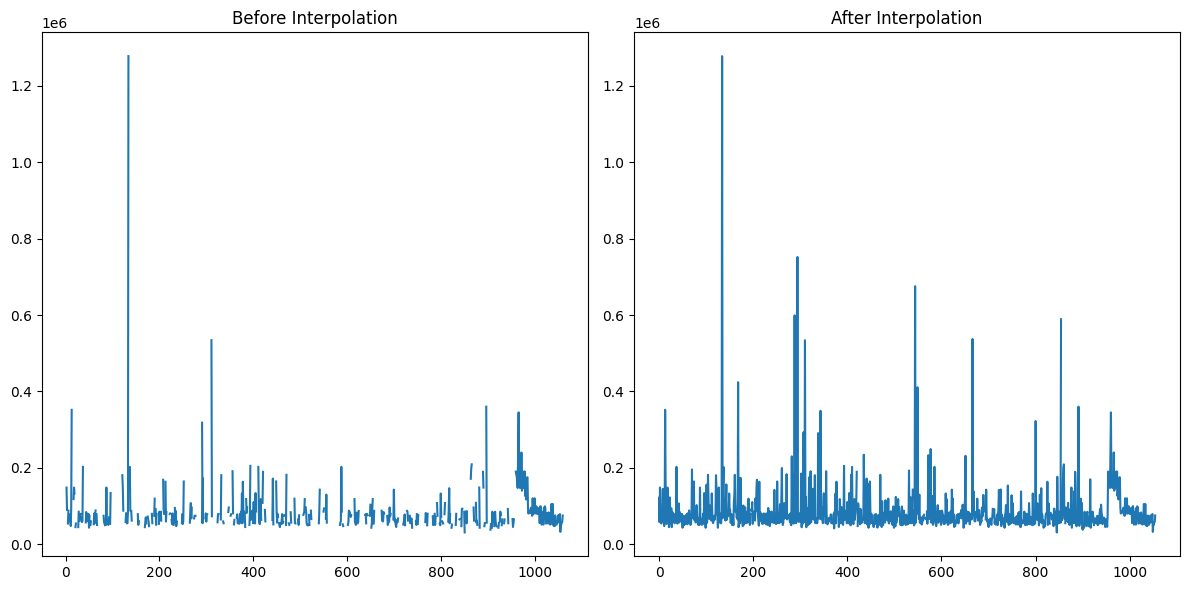

In [104]:
# Create a figure with two subplots side by side
plt.figure(figsize=(12, 6))

# First subplot
plt.subplot(1, 2, 1)
df['ex_showroom_price'].plot(kind='line')
plt.title('Before Interpolation')

# Second subplot
plt.subplot(1, 2, 2)
df1['ex_showroom_price'].plot(kind='line')

plt.title('After Interpolation')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()


Interpolation has helped in filling missing values, making the dataset more complete and usable for analysis.
Peaks are still present, indicating that extreme values or outliers remain unchanged.
This transformation improves data continuity and makes it more suitable for further analysis

In [105]:
df1.isnull().sum()

,0
name,0
selling_price,0
year,0
seller_type,0
owner,0
km_driven,0
ex_showroom_price,17
ex_showroom_missing,0


In [106]:
#Dropping the 17 Null Values
df1.dropna(inplace=True)

In [107]:
df1.reset_index(drop=True, inplace=True)

In [108]:
df1

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price,ex_showroom_missing
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,121370.0,True
1,Honda Dio,45000,2017,Individual,1st owner,5650,57648.0,True
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0,False
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0,False
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,76304.5,True
...,...,...,...,...,...,...,...,...
1033,Activa 3g,17000,2010,Individual,1st owner,500000,52000.0,False
1034,Honda CB twister,16000,2012,Individual,1st owner,33000,51000.0,False
1035,Bajaj Discover 125,15000,2013,Individual,2nd owner,35000,57000.0,False
1036,Honda CB Shine,12000,2009,Individual,1st owner,53000,58000.0,False


In [109]:
df1.drop(columns=['ex_showroom_missing'], inplace=True)

In [110]:
df1.describe()

,selling_price,year,km_driven,ex_showroom_price
count,1038.000000,1038.000000,1038.000000,1.038000e+03
mean,60088.708092,2014.141618,33748.587669,8.702899e+04
std,56531.491171,3.754031,48477.133425,7.026267e+04
min,6000.000000,2001.000000,350.000000,3.049000e+04
25%,29500.000000,2012.000000,13500.000000,5.651416e+04
50%,45000.000000,2015.000000,25000.000000,7.155415e+04
75%,70000.000000,2017.000000,42000.000000,8.674400e+04
max,760000.000000,2020.000000,880000.000000,1.278000e+06


In [111]:
# Q1.What is the range of selling prices in the dataset?

print(f"The range of the selling prices are within {df1.selling_price.min()} - {df1.selling_price.max()}")

The range of the selling prices are within 6000 - 760000


In [112]:
#Q2. What is the median selling price for bikes in the dataset?

print(f"The median selling price is {df.selling_price.median()}")

The median selling price is 45000.0


In [113]:
#Q3.What is the most common seller type?
# Ans: Individual

df1.seller_type.value_counts()

,count
seller_type,
Individual,1033
Dealer,5


The most common seller type are **individuals**

In [114]:
#Q4. How many bikes have driven more than 50,000 kilometers?

# Count the number of bikes that have driven more than 50,000 kilometers
num_bikes_above_50000_km = len(df1[df1.km_driven >= 50000])

print(f"Total number of bikes that have driven more than 50,000 kilometers: {num_bikes_above_50000_km}")


Total number of bikes that have driven more than 50,000 kilometers: 200


In [115]:
#Q5. What is the average km_driven value for each ownership type?

# Assuming your DataFrame is named df1 and contains 'owner' and 'km_driven' columns
avg_km_driven_by_owner = df1.groupby('owner')['km_driven'].mean().reset_index()

# Sort the results by average km_driven
avg_km_driven_by_owner_sorted = round(avg_km_driven_by_owner.sort_values(by='km_driven'),2)

print(avg_km_driven_by_owner_sorted)


       owner  km_driven
0  1st owner   31950.74
1  2nd owner   40071.22
2  3rd owner   40589.25
3  4th owner  443250.00


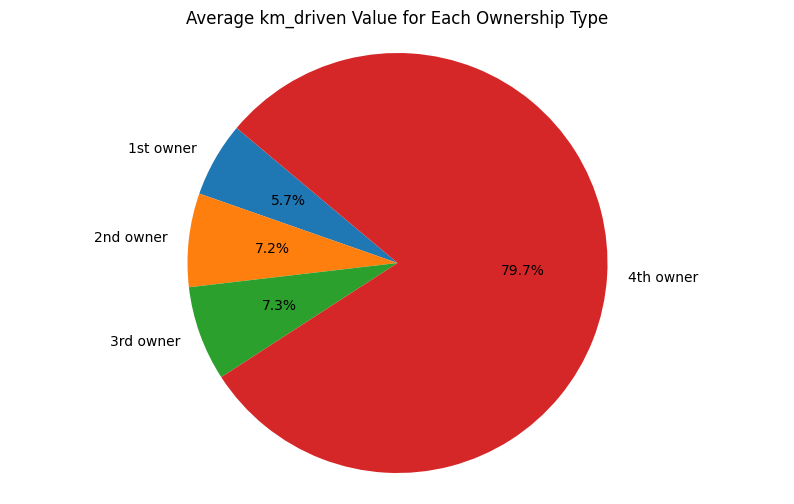

In [116]:
# Create a pie chart
plt.figure(figsize=(10, 6))
plt.pie(avg_km_driven_by_owner_sorted['km_driven'], labels=avg_km_driven_by_owner_sorted['owner'], autopct='%1.1f%%', startangle=140)
plt.title('Average km_driven Value for Each Ownership Type')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


The analysis shows a clear trend: as the number of owners increases, the average km_driven value also increases. This is expected, as older bikes with multiple owners tend to have higher mileage. The significant jump in average km_driven for fourth owners suggests that these bikes have been used extensively and may require more maintenance and repairs.

In [117]:
#Q6. What proportion of bikes are from the year 2015 or older?

bikes_2015_or_older = df1[df1['year'] <= 2015]

proportion = len(bikes_2015_or_older) / len(df)

print(f"The proportion of bikes from the year 2015 or older is: {proportion:.2%}")


The proportion of bikes from the year 2015 or older is: 54.98%


In [118]:
#Q7. What is the trend of missing values across the dataset?

# Check missing values count and percentage
missing_values = df.isna().sum()
missing_percentage = (df.isna().sum() / len(df)) * 100

# Combine the two into a DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
}).sort_values(by='Missing Percentage (%)', ascending=False)

print(missing_summary)


                     Missing Count  Missing Percentage (%)
ex_showroom_price              433               41.042654
name                             0                0.000000
selling_price                    0                0.000000
year                             0                0.000000
seller_type                      0                0.000000
owner                            0                0.000000
km_driven                        0                0.000000
ex_showroom_missing              0                0.000000


In [119]:
#Q8. What is the highest ex_showroom_price recorded, and for which bike?

max_price = df1['ex_showroom_price'].max()
bike_name = df1[df1['ex_showroom_price'] == max_price]['name'].values[0]

print(f"The bike with the highest ex_showroom_price is: {bike_name}, and the recorded price is {max_price}")


The bike with the highest ex_showroom_price is: Harley-Davidson Street Bob, and the recorded price is 1278000.0


In [120]:
#Q9. What is the total number of bikes listed by each seller type?

df1.groupby('seller_type')['name'].count()

,name
seller_type,
Dealer,5
Individual,1033


In [121]:
seller_type_counts = df1['seller_type'].value_counts()

print(seller_type_counts)

print("\nThe total number of bikes listed by each seller type are 1033 and 5 for Individuals and Dealer respectively")


seller_type
Individual    1033
Dealer           5
Name: count, dtype: int64

The total number of bikes listed by each seller type are 1033 and 5 for Individuals and Dealer respectively


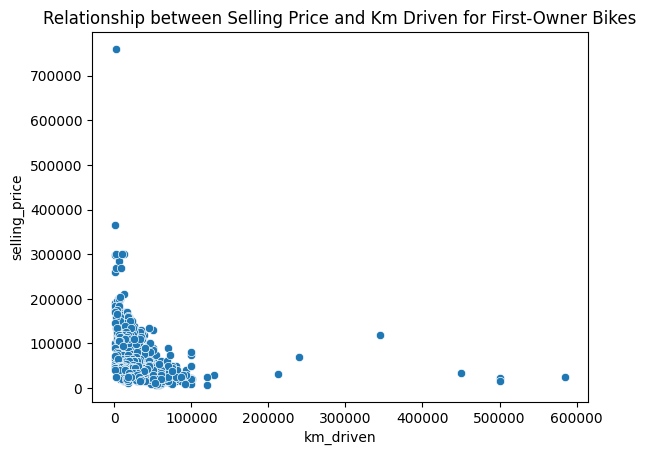

In [122]:
# Q10. What is the relationship between selling_price and km_driven for first-owner bikes?

first_owner_bikes = df1[df1['owner'] == '1st owner']

sns.scatterplot(x='km_driven', y='selling_price', data=first_owner_bikes)
plt.title('Relationship between Selling Price and Km Driven for First-Owner Bikes')
plt.show()


In [123]:
correlation = first_owner_bikes['selling_price'].corr(first_owner_bikes['km_driven'])
print(f"Correlation: {correlation}")

Correlation: -0.25303132046590016


The scatter plot shows a **weak negative correlation (-0.253)** between selling_price and km_driven for first-owner bikes. This indicates that as mileage increases, the **selling price tends to decrease**, but the relationship is not very strong. Most bikes with lower mileage retain higher resale value, while high-mileage bikes generally sell for less.

<Axes: ylabel='km_driven'>

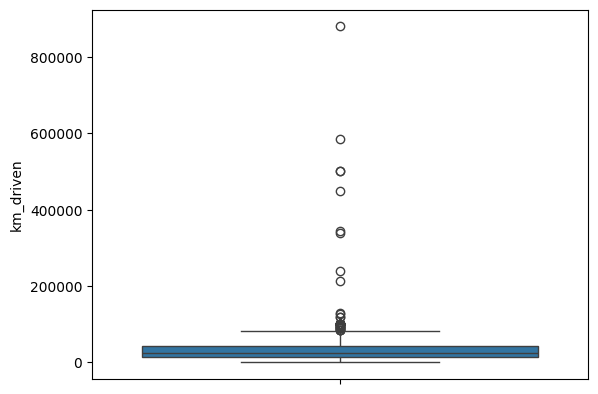

In [124]:
#Q11. Identify and remove outliers in the km_driven column using the IQR method?

sns.boxplot(df1['km_driven'])

In [125]:
df2=df1.copy()

In [126]:
Q1 = df2['km_driven'].quantile(0.25)
Q3 = df2['km_driven'].quantile(0.75)
IQR = Q3 - Q1

# Determine the outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
df2 = df2[(df2['km_driven'] >= lower_bound) & (df2['km_driven'] <= upper_bound)]

print(f"Original dataset size: {df1.shape}")
print(f"Filtered dataset size: {df2.shape}")

Original dataset size: (1038, 7)
Filtered dataset size: (997, 7)


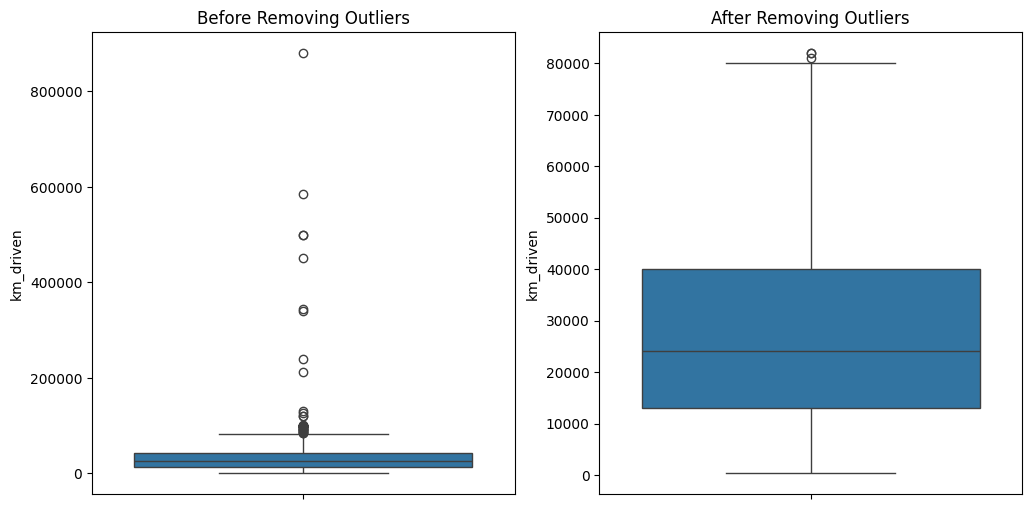

In [127]:
# Comparing the results

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(df1['km_driven'])
plt.title('Before Removing Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(df2['km_driven'])
plt.title('After Removing Outliers')

plt.show()


In [128]:
df2.reset_index(drop=True, inplace=True)

In [129]:
df2

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,121370.0
1,Honda Dio,45000,2017,Individual,1st owner,5650,57648.0
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,76304.5
...,...,...,...,...,...,...,...
992,Hero CBZ Xtreme,20000,2010,Individual,1st owner,50000,78700.0
993,Bajaj ct 100,18000,2017,Individual,1st owner,35000,32000.0
994,Honda CB twister,16000,2012,Individual,1st owner,33000,51000.0
995,Bajaj Discover 125,15000,2013,Individual,2nd owner,35000,57000.0


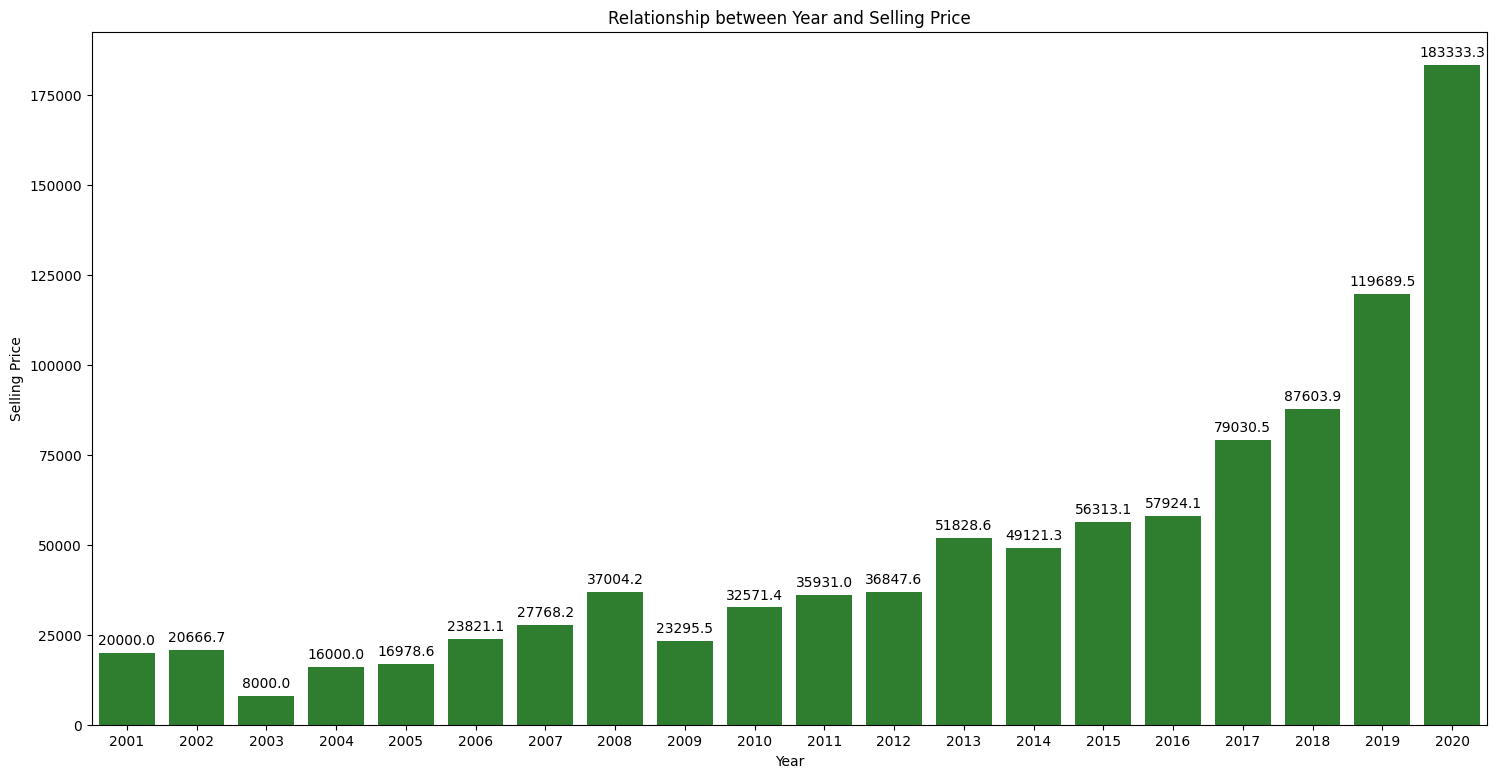

In [130]:
#Q12. Perform a bivariate analysis to visualize the relationship between year and selling_price.

plt.figure(figsize=(18, 9))
barplot = sns.barplot(x='year', y='selling_price', data=df2, color='forestgreen', ci=None)

# Add the numbers on top of each bar
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.1f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points')

plt.title('Relationship between Year and Selling Price')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.show()


Looking at this bar graph showing the relationship between Year and Selling Price from 2001 to 2020, here are the key insights:

1. There's a clear upward trend in selling prices over the years, with significant growth especially after 2015.

2. There's a notable spike in 2020, where the selling price reached its peak at around 183,333.3.

3. The growth wasn't always consistent - there was a dip in 2003 (8,000) compared to 2002 (20,666.7), but after that, the general trend has been upward.

4. The most dramatic increase occurred between 2018 and 2020, where the selling price nearly doubled from around 119,689.5 to 183,333.3.

5. The period from 2001-2010 showed relatively stable prices (ranging between 16,000-37,000) compared to the rapid growth seen in the latter years (2015-2020).

This suggests **a strong positive correlation between year and selling price**, with prices increasing more rapidly in recent years.

In [131]:
#Q13.What is the average depreciation in selling price based on the bike's age (current year - manufacturing year?

df3 = df2.copy()
# Assuming your DataFrame is named df and the current year is 2024
current_year = 2024

# Calculate the age of each bike
df3['age'] = current_year - df3['year']

# Calculate the depreciation for each bike
df3['depreciation'] = df3['ex_showroom_price'] - df3['selling_price']

# Calculate the average depreciation for each age group
average_depreciation = df3.groupby('age')['depreciation'].mean()

print(average_depreciation)



age
4    -27593.333333
5      -983.366279
6     10200.973077
7     14176.190840
8     24973.669903
9     28689.297980
10    33485.325843
11    47865.735714
12    31504.850088
13    47318.938697
14    49697.691964
15    39443.109307
16    35794.196429
17    40580.037879
18    27774.482456
19    37818.845238
20    38852.000000
21    46852.000000
22    34185.333333
23    34852.000000
Name: depreciation, dtype: float64


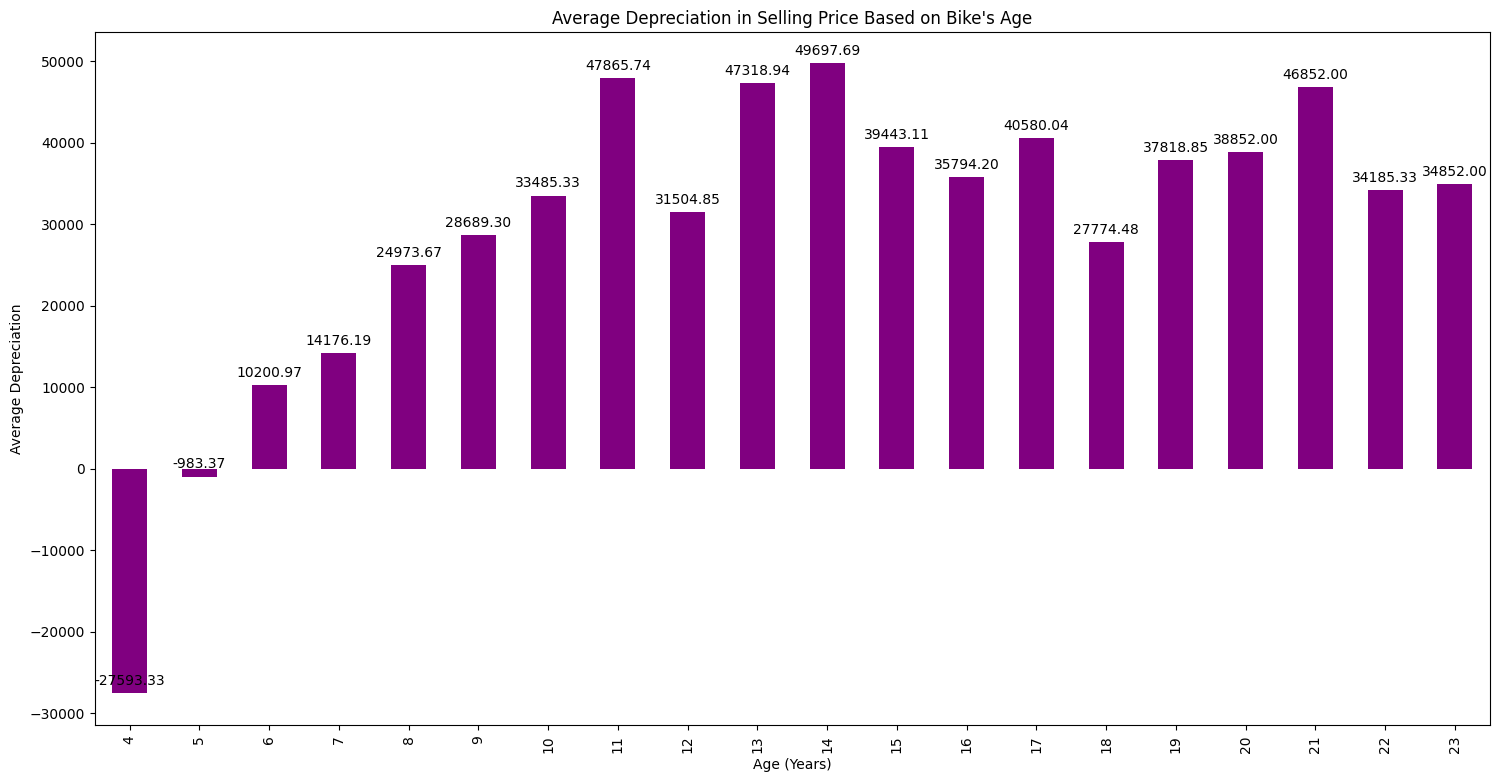

In [132]:
# Plot the average depreciation
plt.figure(figsize=(18, 9))
barplot = average_depreciation.plot(kind='bar', color='purple')

# Add the numbers on top of each bar
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.2f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 9),
                     textcoords='offset points')

plt.title('Average Depreciation in Selling Price Based on Bike\'s Age')
plt.xlabel('Age (Years)')
plt.ylabel('Average Depreciation')
plt.show()


The bike depreciation analysis shows significant value loss between 10-15 years, with peak depreciation at 14 years (₹49,697). Newer bikes (4-5 years) maintain value better, even showing slight appreciation. After 15 years, depreciation stabilizes around ₹35,000-40,000, suggesting a floor in value loss.

In [133]:
#Q14. Which bike names are priced significantly above the average price for their manufacturing year?

df4 = df3.copy()

# Calculate the average selling price for each manufacturing year
average_price_by_year = df4.groupby('year')['selling_price'].mean()

# Merge the average prices back to the original DataFrame
df4 = df4.merge(average_price_by_year, on='year', suffixes=('', '_avg'))

# Identify bikes priced significantly above the average (e.g., 20% above the average)
threshold = 1.20
df_above_avg = df4[df4['selling_price'] > df4['selling_price_avg'] * threshold]

# Display the bike names and their selling prices
above_avg_bikes = df_above_avg[['name', 'selling_price', 'year']]
above_avg_bikes.name.value_counts()

,count
name,
Royal Enfield Classic 350,23
Royal Enfield Thunderbird 350,19
Royal Enfield Thunderbird 350X,7
Royal Enfield Classic Gunmetal Grey,6
Royal Enfield Electra 5 S,6
...,...
Bajaj Avenger Street 150 [2018],1
Bajaj Pulsar NS200,1
Harley-Davidson Street Bob,1


<Axes: >

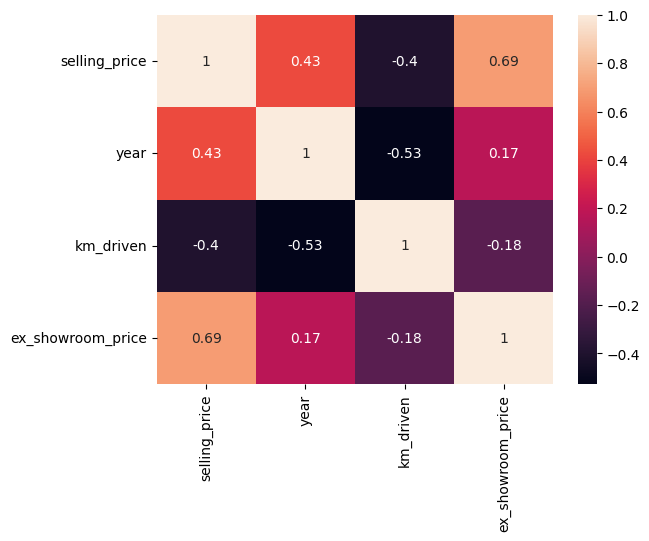

In [134]:
#Q15. Develop a correlation matrix for numeric columns and visualize it using a heatmap?

corr_mat = df3.drop(['depreciation','age'], axis=1)
sns.heatmap(corr_mat.corr(numeric_only= True), annot= True)

The heatmap reveals that the selling price of bikes is strongly influenced by the showroom price (positive correlation of 0.69) and moderately by the manufacturing year (0.42). Higher mileage negatively impacts the selling price (-0.4) and is strongly tied to older bikes (-0.53 with year). These insights align with market trends, where newer and pricier bikes retain higher resale values, while high mileage reduces resale appeal

# EDA - Car sales

The dataset provided focuses on used car sales, capturing various attributes to analyze the second-hand car
market. It provides insights into factors affecting resale value, trends in the used car industry, and
consumer behavior.

 The dataset contains details about used cars listed for sale, such as brand, model, selling price, kilometers
driven, fuel type, and transmission type. This information is valuable for predictive modeling, market analysis,
and understanding customer preferences.

**Features:**

 - **Car_id:** A unique identifier for each car in the dataset, helping to track individual car entries
 - **Date:** The date when the car sale transaction took place, formatted as YYYY-MM-DD
 - **Customer Name:** The name of the customer who purchased the car, represented as a string
 - **Gender:** The gender of the customer, categorized as "Male" or "Female.
 - **Annual Income:** The customer's annual income in US dollars, represented as a numeric value
 - **Dealer_Name:** The name of the dealership selling the car, represented as a string
 - **Company:** The manufacturer or brand name of the car, such as "Toyota," "Ford," etc
 - **Model:** The specific model name of the car, such as "Corolla," "Civic," etc Engine: The engine type of the car, such as "V6," "I4," etc
 - **Price ($):** The selling price of the car in US dollars
 - **Transmission:** The type of transmission in the car, either "Manual" or "Automatic.
 - **Color:** The color of the car, represented as a string (e.g., "Red," "Blue")
 - **Dealer_No:** A unique identifier for each car dealer in the dataset
 - **Body Style:** The body style of the car, such as "Sedan," "SUV," etc
 - **Phone:** The phone number of the customer who purchased the car
 - **Dealer_Region:** The geographical region of the car dealer, such as "North," "South," etc.

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [136]:
car_sales_df = pd.read_csv("/content/Car Sale.csv")
car_sales_df

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23901,C_CND_023902,12/31/2023,Martin,Male,13500,C & M Motors Inc,Plymouth,Voyager,Overhead Camshaft,Manual,Red,12000,60504-7114,Passenger,8583598,Pasco
23902,C_CND_023903,12/31/2023,Jimmy,Female,900000,Ryder Truck Rental and Leasing,Chevrolet,Prizm,DoubleÂ Overhead Camshaft,Auto,Black,16000,06457-3834,Hardtop,7914229,Middletown
23903,C_CND_023904,12/31/2023,Emma,Male,705000,Chrysler of Tri-Cities,BMW,328i,Overhead Camshaft,Manual,Red,21000,99301-3882,Sedan,7659127,Scottsdale
23904,C_CND_023905,12/31/2023,Victoire,Male,13500,Chrysler Plymouth,Chevrolet,Metro,DoubleÂ Overhead Camshaft,Auto,Black,31000,53546-9427,Passenger,6030764,Austin


In [137]:
cs = car_sales_df.copy()

In [138]:
cs.shape

(23906, 16)

In [139]:
cs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car_id         23906 non-null  object
 1   Date           23906 non-null  object
 2   Customer Name  23905 non-null  object
 3   Gender         23906 non-null  object
 4   Annual Income  23906 non-null  int64 
 5   Dealer_Name    23906 non-null  object
 6   Company        23906 non-null  object
 7   Model          23906 non-null  object
 8   Engine         23906 non-null  object
 9   Transmission   23906 non-null  object
 10  Color          23906 non-null  object
 11  Price ($)      23906 non-null  int64 
 12  Dealer_No      23906 non-null  object
 13  Body Style     23906 non-null  object
 14  Phone          23906 non-null  int64 
 15  Dealer_Region  23906 non-null  object
dtypes: int64(3), object(13)
memory usage: 2.9+ MB


In [140]:
cs.dtypes

,0
Car_id,object
Date,object
Customer Name,object
Gender,object
Annual Income,int64
Dealer_Name,object
Company,object
Model,object
Engine,object
Transmission,object


In [141]:
cs.describe()

,Annual Income,Price ($),Phone
count,2.390600e+04,23906.000000,2.390600e+04
mean,8.308403e+05,28090.247846,7.497741e+06
std,7.200064e+05,14788.687608,8.674920e+05
min,1.008000e+04,1200.000000,6.000101e+06
25%,3.860000e+05,18001.000000,6.746495e+06
50%,7.350000e+05,23000.000000,7.496198e+06
75%,1.175750e+06,34000.000000,8.248146e+06
max,1.120000e+07,85800.000000,8.999579e+06


In [142]:
# Finding the total null values
cs.isnull().sum()

,0
Car_id,0
Date,0
Customer Name,1
Gender,0
Annual Income,0
Dealer_Name,0
Company,0
Model,0
Engine,0
Transmission,0


In [143]:
# Removing the Null values
cs = cs.dropna()

In [144]:
cs.reset_index(drop=True, inplace=True)

In [145]:
cs

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23900,C_CND_023902,12/31/2023,Martin,Male,13500,C & M Motors Inc,Plymouth,Voyager,Overhead Camshaft,Manual,Red,12000,60504-7114,Passenger,8583598,Pasco
23901,C_CND_023903,12/31/2023,Jimmy,Female,900000,Ryder Truck Rental and Leasing,Chevrolet,Prizm,DoubleÂ Overhead Camshaft,Auto,Black,16000,06457-3834,Hardtop,7914229,Middletown
23902,C_CND_023904,12/31/2023,Emma,Male,705000,Chrysler of Tri-Cities,BMW,328i,Overhead Camshaft,Manual,Red,21000,99301-3882,Sedan,7659127,Scottsdale
23903,C_CND_023905,12/31/2023,Victoire,Male,13500,Chrysler Plymouth,Chevrolet,Metro,DoubleÂ Overhead Camshaft,Auto,Black,31000,53546-9427,Passenger,6030764,Austin


In [146]:
cs.duplicated().sum()

0

In [147]:
cs1 = cs.copy()

In [148]:
cs1.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

In [149]:
# Drop the columns 'Customer Name', 'Dealer_No', and 'Phone' from the DataFrame
# This is done to remove unnecessary or sensitive information from the dataset

cs1.drop(['Customer Name', 'Dealer_No ', 'Phone'], axis=1, inplace=True)

In [150]:
# Rename columns to make them more consistent and easier to work with
# 'Price ($)' to 'Price'
# 'Body Style' to 'Body_Style'
# 'Annual Income' to 'Annual_Income'

cs1.rename(columns={'Price ($)': 'Price', 'Body Style': 'Body_Style', 'Annual Income': 'Annual_Income'}, inplace=True)

In [151]:
cs1['Engine'].unique()

array(['DoubleÂ\xa0Overhead Camshaft', 'Overhead Camshaft'], dtype=object)

After thoroughly checking each column using the .unique() method, no potential errors were found.

In [152]:
cs1['Date'] = pd.to_datetime(cs1['Date'])

In [153]:
cs1.dtypes

,0
Car_id,object
Date,datetime64[ns]
Gender,object
Annual_Income,int64
Dealer_Name,object
Company,object
Model,object
Engine,object
Transmission,object
Color,object


In [154]:
# Extract the month and year from the date of sale
cs1['Day'] = pd.to_datetime(cs1['Date']).dt.day
cs1['Month'] = pd.to_datetime(cs1['Date']).dt.month
cs1['Year'] = pd.to_datetime(cs1['Date']).dt.year

In [155]:
cs1.drop(['Date'], axis=1,inplace=True)

In [156]:
cs1

,Car_id,Gender,Annual_Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price,Body_Style,Dealer_Region,Day,Month,Year
0,C_CND_000001,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,SUV,Middletown,2,1,2022
1,C_CND_000002,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,SUV,Aurora,2,1,2022
2,C_CND_000003,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,Passenger,Greenville,2,1,2022
3,C_CND_000004,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,SUV,Pasco,2,1,2022
4,C_CND_000005,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,Hatchback,Janesville,2,1,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23900,C_CND_023902,Male,13500,C & M Motors Inc,Plymouth,Voyager,Overhead Camshaft,Manual,Red,12000,Passenger,Pasco,31,12,2023
23901,C_CND_023903,Female,900000,Ryder Truck Rental and Leasing,Chevrolet,Prizm,DoubleÂ Overhead Camshaft,Auto,Black,16000,Hardtop,Middletown,31,12,2023
23902,C_CND_023904,Male,705000,Chrysler of Tri-Cities,BMW,328i,Overhead Camshaft,Manual,Red,21000,Sedan,Scottsdale,31,12,2023
23903,C_CND_023905,Male,13500,Chrysler Plymouth,Chevrolet,Metro,DoubleÂ Overhead Camshaft,Auto,Black,31000,Passenger,Austin,31,12,2023


In [157]:
# Q1. What is the average selling price of cars for each dealer, and how does it compare across different dealers?

# Group the data by dealer and calculate the average selling price
average_price_by_dealer = cs1.groupby('Dealer_Name')['Price'].mean().reset_index()
average_price_by_dealer.columns = ['Dealer_Name', 'Average_Selling_Price']

# Display the average selling prices for each dealer
print(average_price_by_dealer)

                                        Dealer_Name  Average_Selling_Price
0               Buddy Storbeck's Diesel Service Inc           27217.261563
1                                  C & M Motors Inc           28111.755200
2                                       Capitol KIA           28189.703822
3                                 Chrysler Plymouth           27555.526400
4                            Chrysler of Tri-Cities           28123.091054
5                                     Classic Chevy           28602.014446
6                           Clay Johnson Auto Sales           27816.027113
7                                Diehl Motor CO Inc           27993.929487
8                             Enterprise Rent A Car           28312.580800
9                        Gartner Buick Hyundai Saab           28247.621019
10                              Hatfield Volkswagen           27853.712242
11                                  Iceberg Rentals           28522.958533
12                     Mc

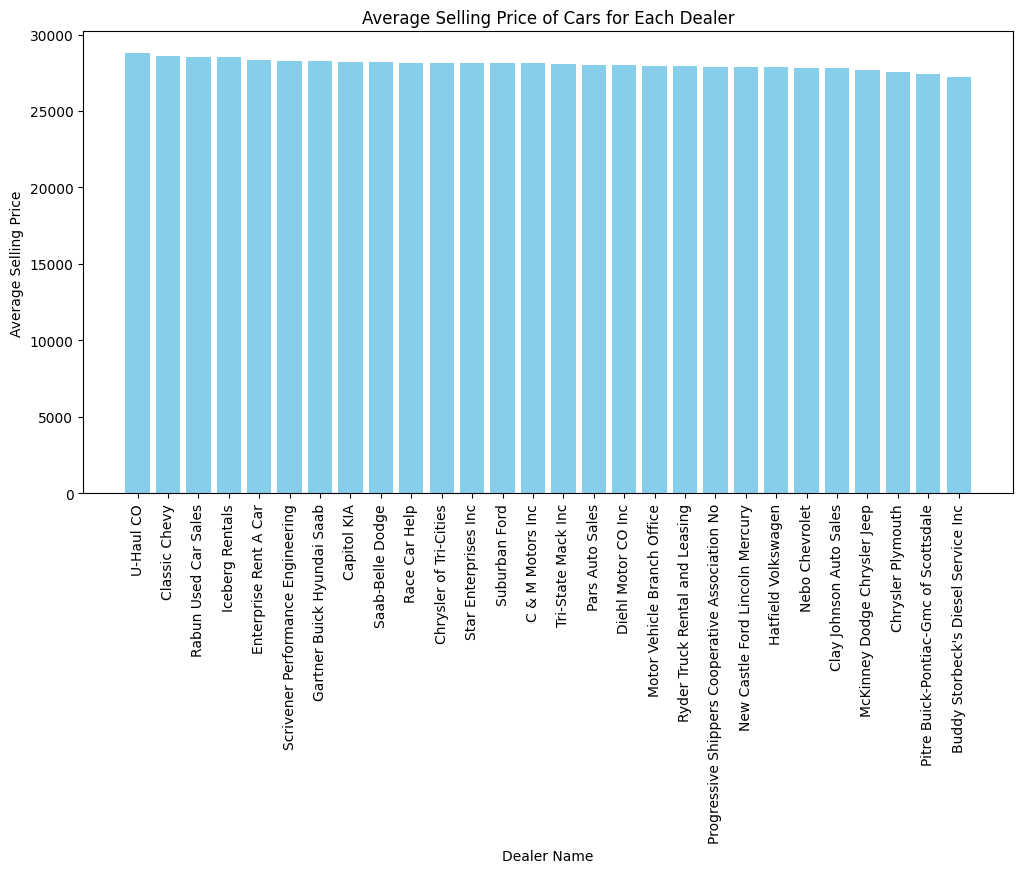

In [158]:
# Visualize the comparison using a bar plot

plt.figure(figsize=(12, 6))
average_price_by_dealer.sort_values(by='Average_Selling_Price', ascending=False, inplace=True)
plt.bar(average_price_by_dealer['Dealer_Name'], average_price_by_dealer['Average_Selling_Price'], color='skyblue')
plt.xticks(rotation=90)
plt.title('Average Selling Price of Cars for Each Dealer')
plt.xlabel('Dealer Name')
plt.ylabel('Average Selling Price')
plt.show()

The average selling prices across dealers are consistently within the 25,000-30,000 range. This indicates a fairly standardized market with limited price variation between dealers. The minimal variation in average prices suggests a highly competitive market where dealers must maintain a tight price range to stay competitive

In [159]:
#Q2. Which car brand (Company) has the highest variation in prices, and what does this tell us about the pricing trends

# Calculate the standard deviation of prices for each car brand
price_variation_by_brand = cs1.groupby('Company')['Price'].std().reset_index()
price_variation_by_brand.columns = ['Company', 'Price_Variation']

In [160]:
price_variation_by_brand.sort_values('Price_Variation', ascending= False, inplace=True)

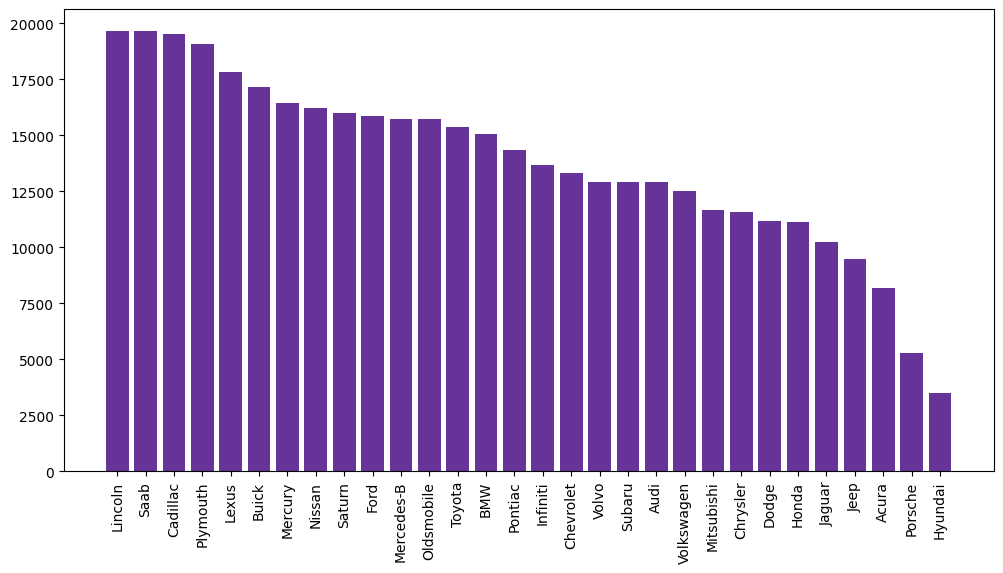

In [161]:
plt.figure(figsize=(12, 6))
plt.bar(price_variation_by_brand.Company, price_variation_by_brand.Price_Variation, color='rebeccapurple')
plt.xticks(rotation=90)
plt.show()

In [162]:
price_variation_by_brand_reset = price_variation_by_brand.head(3).reset_index(drop=True)

# Adjust the index to start from 1
price_variation_by_brand_reset.index = price_variation_by_brand_reset.index + 1

print(price_variation_by_brand_reset)


    Company  Price_Variation
1   Lincoln     19658.050211
2      Saab     19653.740089
3  Cadillac     19517.120220


Lincoln, Saab, and Cadillac are within a close range in terms of price, variation with Lincoln having the highest in variation, indicating a wide range of models with varying prices. This suggests that these brands offer a diverse lineup, catering to different market segments from budget-friendly to luxury models. The high price variation implies a flexible pricing strategy and adaptability in meeting various customer needs and preferences.

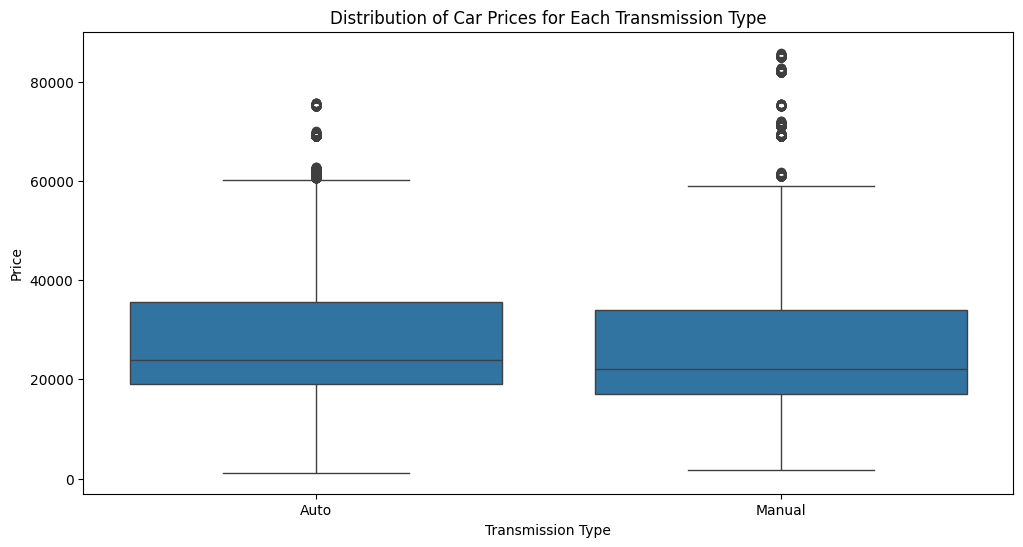

In [163]:
#Q3. What is the distribution of car prices for each transmission type, and how do the interquartile ranges compare?

# Create a box plot to visualize the distribution of car prices for each transmission type
plt.figure(figsize=(12, 6))
sns.boxplot(x='Transmission', y='Price', data=cs1)
plt.title('Distribution of Car Prices for Each Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Price')
plt.show()


In [164]:
# Group by 'Transmission' and compute summary statistics
transmission_stats = cs1.groupby('Transmission')['Price'].describe()

# Calculate IQR for each transmission type
transmission_stats['IQR'] = transmission_stats['75%'] - transmission_stats['25%']
print(transmission_stats[['25%', '50%', '75%', 'IQR']])


                  25%      50%      75%      IQR
Transmission                                    
Auto          19000.0  24000.0  35500.0  16500.0
Manual        17000.0  22001.0  34000.0  17000.0


Automatic cars have a slightly higher median price (24,000) compared to manual cars (22,001), indicating they are generally more expensive. The price variability, measured by the interquartile range (IQR), is similar, with manual cars showing a slightly larger IQR (17,000 vs. 16,500), suggesting slightly more price spread. Both transmission types exhibit upper-end outliers, more pronounced in manual cars, possibly due to premium models. Overall, automatic cars tend to command higher prices, likely reflecting their convenience and market demand.

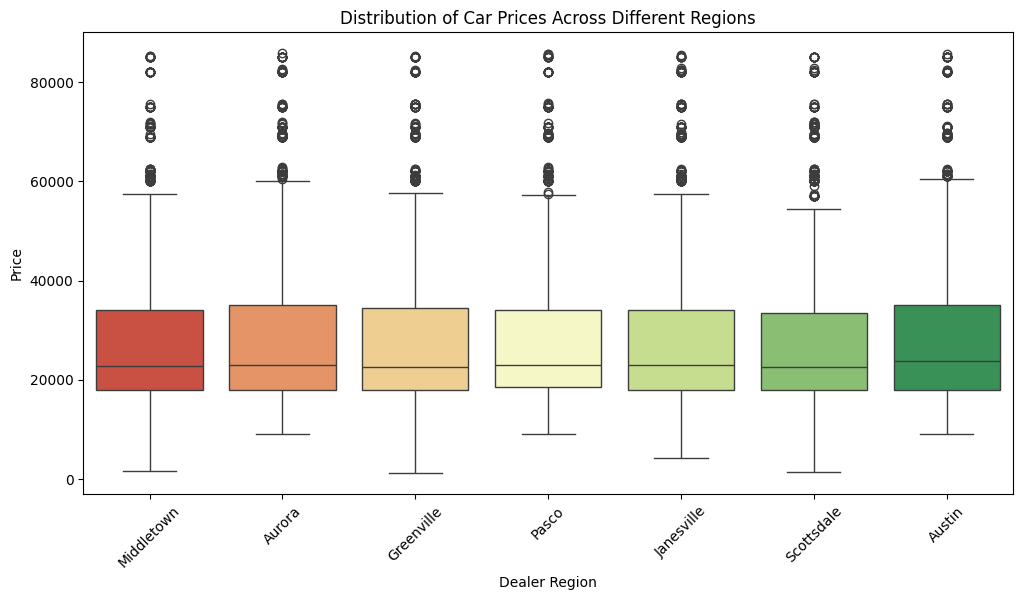

                count          mean           std     min      25%      50%  \
Dealer_Region                                                                 
Aurora         3129.0  28329.300735  15025.653685  9000.0  18001.0  23000.0   
Austin         4135.0  28341.603628  14903.884549  9000.0  18001.0  23801.0   
Greenville     3128.0  28180.819054  15101.538328  1200.0  18001.0  22500.0   
Janesville     3821.0  27833.350955  14344.995638  4300.0  18001.0  23000.0   
Middletown     3128.0  27856.338875  14619.842395  1700.0  18000.0  22750.0   
Pasco          3131.0  28119.039923  14659.315941  9000.0  18500.5  23000.0   
Scottsdale     3433.0  27954.958928  14902.916820  1450.0  18000.0  22600.0   

                   75%      max  
Dealer_Region                    
Aurora         35000.0  85800.0  
Austin         35001.0  85601.0  
Greenville     34500.0  85200.0  
Janesville     34000.0  85400.0  
Middletown     34000.0  85300.0  
Pasco          34000.0  85600.0  
Scottsdale     3

In [165]:
#Q4. What is the distribution of car prices across different regions?

# Boxplot to visualize distribution of prices by region
plt.figure(figsize=(12, 6))
sns.boxplot(data=cs1, x='Dealer_Region', y='Price', palette='RdYlGn')
plt.title('Distribution of Car Prices Across Different Regions')
plt.xlabel('Dealer Region')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()

# Summary statistics
region_stats = cs1.groupby('Dealer_Region')['Price'].describe()
print(region_stats)



The distribution of car prices across regions shows similar patterns, with median prices ranging from 22,500 to 23,800 and interquartile ranges (IQR) around 16,000 to 17,000, indicating consistent pricing trends. Aurora, Austin, and Pasco have slightly higher maximum prices (approx. 85,800), suggesting a stronger presence of high-end vehicles. Variations in the means and standard deviations indicate some regional differences, but overall, pricing remains fairly uniform across regions.

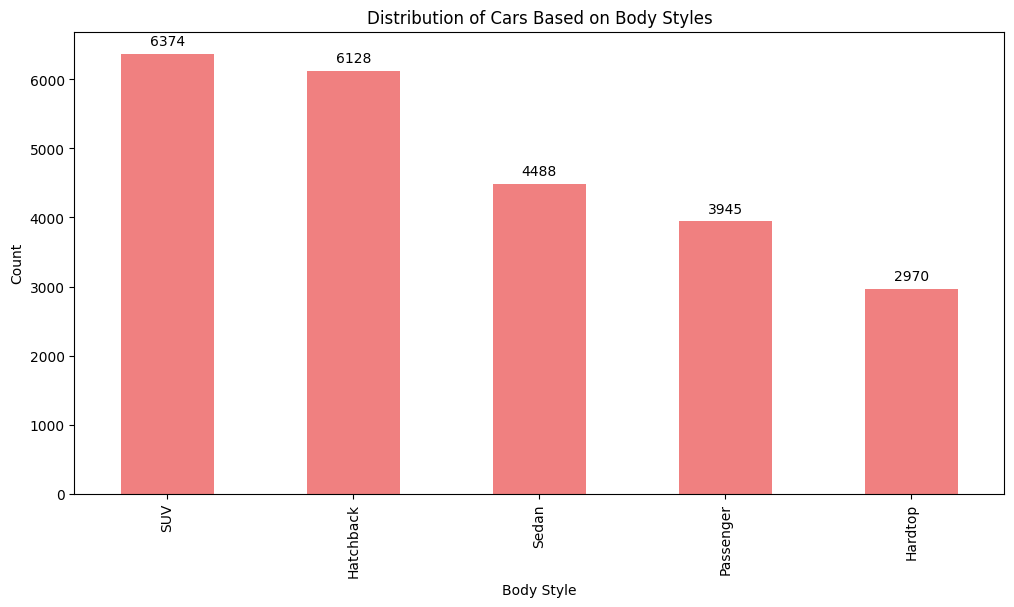

In [166]:
#Q5. What is the distribution of cars based on body styles?

# Count the number of cars for each body style
body_style_counts = cs1['Body_Style'].value_counts()

# Create a bar chart to visualize the distribution
plt.figure(figsize=(12, 6))
barplot = body_style_counts.plot(kind='bar', color='lightcoral')

# Add the count on top of each bar
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.0f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points')

plt.title('Distribution of Cars Based on Body Styles')
plt.xlabel('Body Style')
plt.ylabel('Count')
plt.show()


The data shows a clear hierarchy in vehicle preferences, with SUVs leading at 6,374 units, closely followed by Hatchbacks at 6,128 units. These two body styles together dominate the market, likely due to their versatility and practicality. The middle segment is represented by Sedans with 4,488 units, while Passenger vehicles (3,945) and Hardtops (2,970) make up the lower tier. This distribution reflects a strong market preference for utility vehicles with flexible space options, though the presence of significant numbers across all categories suggests a diverse market that caters to various consumer needs.

In [167]:
cs2 = cs1.copy()

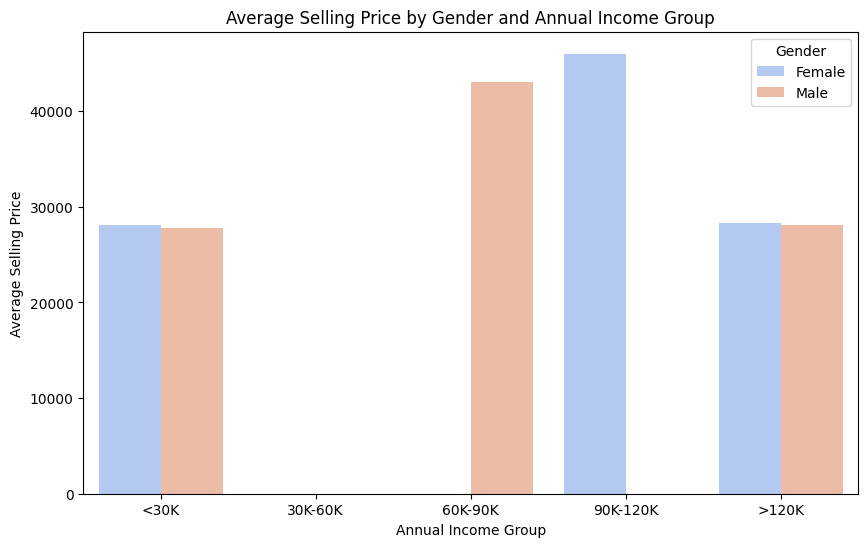

In [168]:
#Q6. How does the average selling price of cars vary by customer gender and annual income?

# Create income bins for grouping
income_bins = [0, 30000, 60000, 90000, 120000, float('inf')]
income_labels = ['<30K', '30K-60K', '60K-90K', '90K-120K', '>120K']
cs2['Income_Group'] = pd.cut(cs2['Annual_Income'], bins=income_bins, labels=income_labels)

# Group by Gender and Income Group to calculate average selling price
avg_price = cs2.groupby(['Gender', 'Income_Group'])['Price'].mean().reset_index()

# Plotting the results
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_price, x='Income_Group', y='Price', hue='Gender', palette='coolwarm')
plt.title('Average Selling Price by Gender and Annual Income Group')
plt.xlabel('Annual Income Group')
plt.ylabel('Average Selling Price')
plt.legend(title='Gender')
plt.show()


The data reveals interesting purchase patterns across income groups and genders. The highest average selling prices peak in the 90K-120K income bracket for both genders, with females showing slightly higher purchases than males in this range. Notably, both the lowest (<30K) and highest (>120K) income groups show similar average purchase values around 28K, regardless of gender.

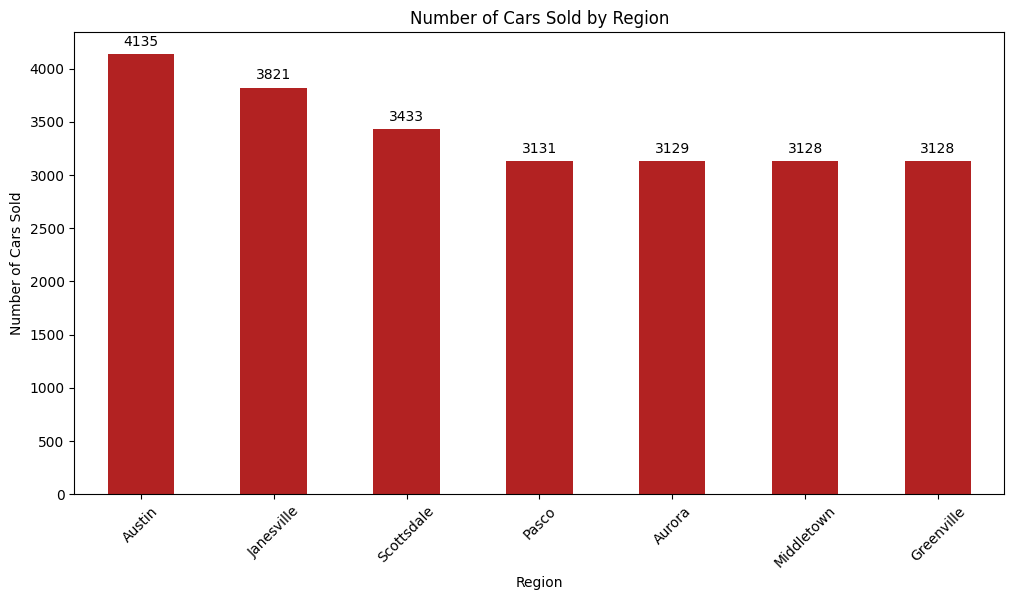

In [169]:
#Q7. What is the distribution of car prices by region, and how does the number of cars sold vary by region?

''' First part to the question done in Q4'''

# Count the number of cars sold in each region
cars_sold_by_region = cs1['Dealer_Region'].value_counts()

# Create a bar chart to visualize the distribution
plt.figure(figsize=(12, 6))
barplot = cars_sold_by_region.plot(kind='bar', color='firebrick')

# Add the count on top of each bar
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.0f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points')

plt.title('Number of Cars Sold by Region')
plt.xlabel('Region')
plt.ylabel('Number of Cars Sold')
plt.xticks(rotation=45)
plt.show()


Austin dominates the market with 4,135 cars sold, followed by Janesville (3,821) and Scottsdale (3,433), showing clear regional leaders in sales volume. Interestingly, the remaining regions (Pasco, Aurora, Middletown, and Greenville) all demonstrate remarkably consistent sales figures around 3,100 units, suggesting similar market conditions in these areas.

In [170]:
#Q8. How does the average car price differ between cars with different engine sizes?

# Group by engine size and calculate the average car price
avg_price_by_engine_size = cs1.groupby('Engine')['Price'].mean().reset_index()

# Display the average car prices for each engine size group
print(avg_price_by_engine_size)


                      Engine         Price
0  DoubleÂ Overhead Camshaft  28247.193317
1          Overhead Camshaft  27914.710631


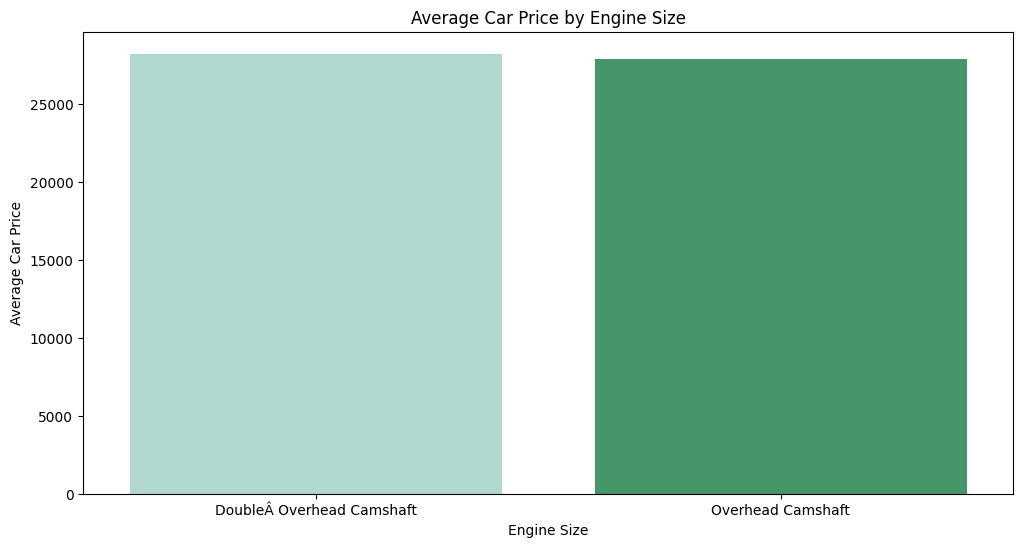

In [171]:
# Visualize the results using a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Engine', y='Price', data=avg_price_by_engine_size, palette='BuGn')
plt.title('Average Car Price by Engine Size')
plt.xlabel('Engine Size')
plt.ylabel('Average Car Price')
plt.show()

The average prices do not vary significantly across different engine sizes. This suggests that engine size alone is not a major determinant of car prices. The minimal variation in average prices across engine sizes indicates that customers may prioritize other attributes over engine size when making purchasing decisions.

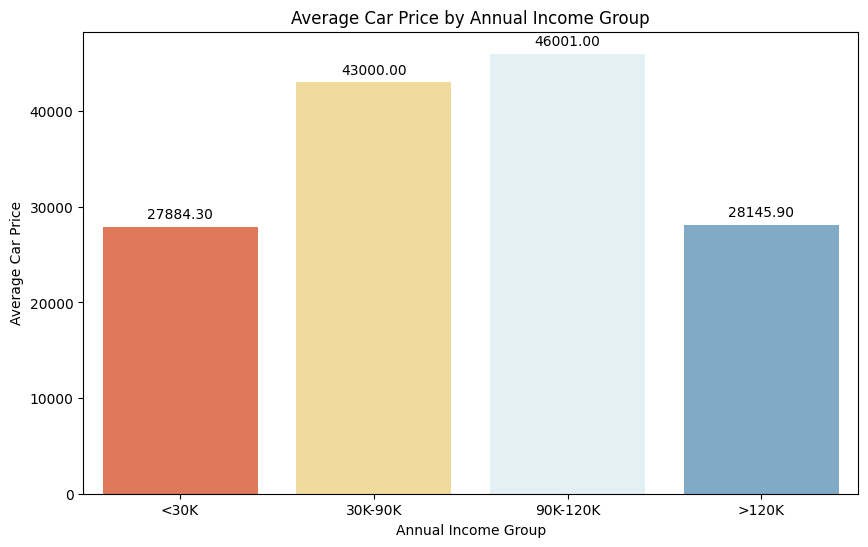

In [172]:
#Q9. How do car prices vary based on the customer’s annual income bracket?

# Create new income bins for grouping
income_bins = [0, 30000, 90000, 120000, float('inf')]
income_labels = ['<30K', '30K-90K', '90K-120K', '>120K']
cs2['Income_Group'] = pd.cut(cs2['Annual_Income'], bins=income_bins, labels=income_labels)

# Group by Income Group to calculate average car price
avg_price_by_income = cs2.groupby('Income_Group')['Price'].mean().reset_index()

# Plotting the results
plt.figure(figsize=(10,6))
barplot = sns.barplot(data=avg_price_by_income, x='Income_Group', y='Price', palette='RdYlBu')

# Add the average price above each bar
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.2f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points')

plt.title('Average Car Price by Annual Income Group')
plt.xlabel('Annual Income Group')
plt.ylabel('Average Car Price')
plt.show()


The highest average car price is found in the 90K-120K income bracket (46,001), followed by the 30K-90K group (43,000), showing peak spending in middle-to-upper income ranges. Surprisingly, both the lowest (above 30K) and highest (under 120K) income groups show similar average car prices around 27,000 - 28,000, suggesting that income level isn't directly proportional to car spending. This indicates that factors beyond income, such as personal preferences, financial priorities, or financing options, likely play significant roles in car purchase decisions.

In [173]:
#10.  What are the top 5 car models with the highest number of sales, and how does their price distribution look?

# Identify the top 5 car models with the highest number of sales
top_5_models = cs1['Model'].value_counts().head(5).index
df_top_5_models = cs1[cs1['Model'].isin(top_5_models)]
df_top_5_models

,Car_id,Gender,Annual_Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price,Body_Style,Dealer_Region,Day,Month,Year
5,C_CND_000006,Male,850000,Classic Chevy,Mitsubishi,Diamante,Overhead Camshaft,Manual,Pale White,12000,Hatchback,Scottsdale,2,1,2022
24,C_CND_000025,Male,672000,Suburban Ford,Volkswagen,Jetta,DoubleÂ Overhead Camshaft,Auto,Pale White,22000,Passenger,Janesville,2,1,2022
69,C_CND_000070,Male,13500,Clay Johnson Auto Sales,Mitsubishi,Diamante,DoubleÂ Overhead Camshaft,Auto,Pale White,21000,Hatchback,Pasco,4,1,2022
74,C_CND_000075,Male,1097000,Progressive Shippers Cooperative Association No,Volkswagen,Jetta,DoubleÂ Overhead Camshaft,Auto,Black,22700,Passenger,Janesville,5,1,2022
107,C_CND_000108,Male,1362000,Chrysler of Tri-Cities,Chevrolet,Prizm,Overhead Camshaft,Manual,Pale White,21200,Hardtop,Pasco,6,1,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23812,C_CND_023814,Male,13500,Chrysler of Tri-Cities,Mitsubishi,Diamante,DoubleÂ Overhead Camshaft,Auto,Black,17000,Hatchback,Scottsdale,29,12,2023
23833,C_CND_023835,Male,716000,New Castle Ford Lincoln Mercury,Volkswagen,Passat,Overhead Camshaft,Manual,Red,20000,Hatchback,Aurora,30,12,2023
23867,C_CND_023869,Female,13500,Star Enterprises Inc,Volkswagen,Passat,DoubleÂ Overhead Camshaft,Auto,Pale White,31000,Hatchback,Scottsdale,30,12,2023
23881,C_CND_023883,Male,501000,Suburban Ford,Chevrolet,Prizm,Overhead Camshaft,Manual,Red,22001,Hatchback,Janesville,31,12,2023


In [174]:
top_5_models

Index(['Diamante', 'Silhouette', 'Prizm', 'Passat', 'Jetta'], dtype='object', name='Model')

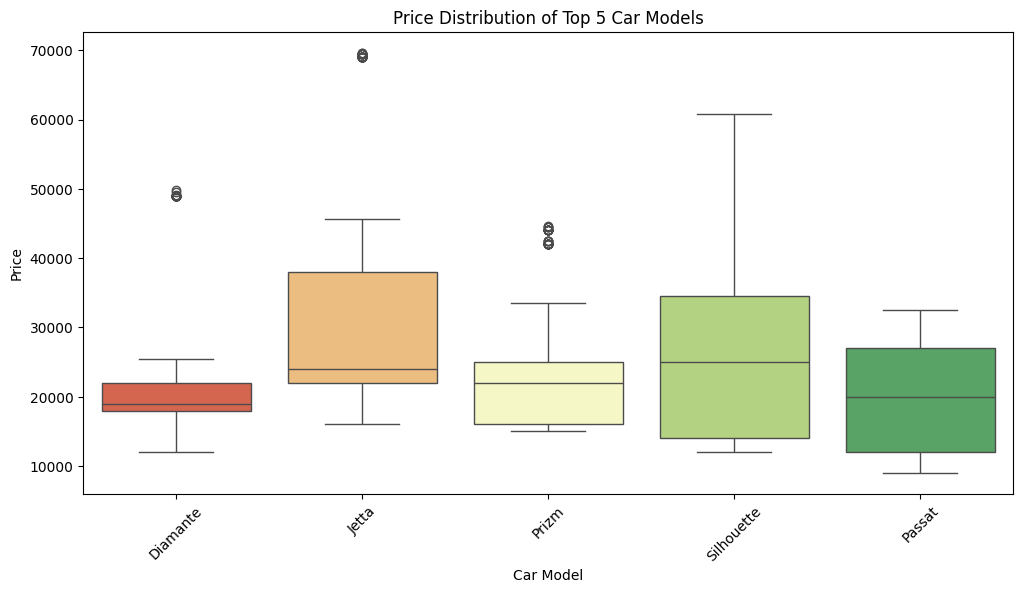

In [175]:
# Plotting the price distribution using a box plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='Model', y='Price', data=df_top_5_models, palette='RdYlGn')
plt.title('Price Distribution of Top 5 Car Models')
plt.xlabel('Car Model')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()

Among the top sellers, Silhouette and Jetta command the highest median prices (25,000 and 24,000 respectively), while Diamante has the lowest (19,001). The box plot reveals Silhouette has the widest price range (12K-60K), while Jetta shows notable high-end outliers up to 70K. Despite their different price positioning, all five models achieve high sales volumes, suggesting successful targeting of different market segments. Diamante and Prizm shows the most concentrated price distribution, indicating consistent pricing strategy compared to the others.

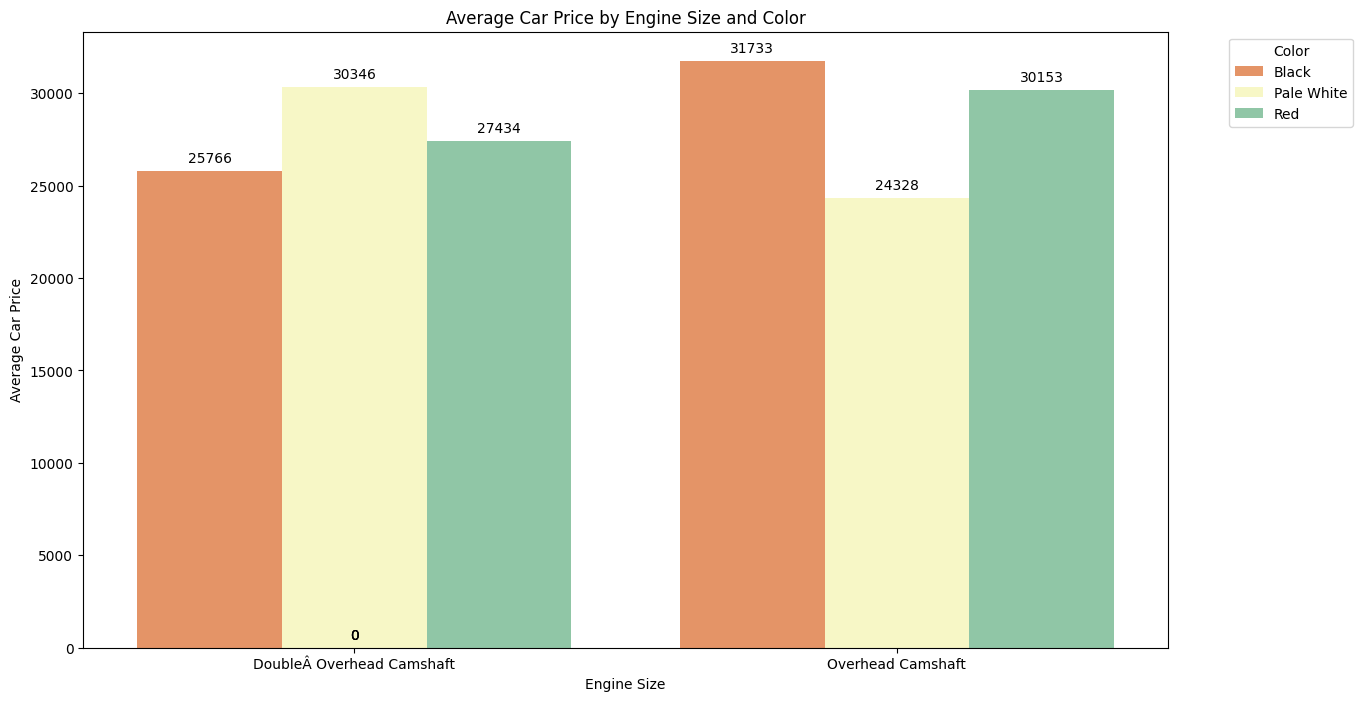

In [176]:
#Q11. How does car price vary with engine size across different car colors, and which colors have the highest price variation?

# Group by Engine Size and Color to calculate average car price
avg_price_by_engine_color = cs1.groupby(['Engine', 'Color'])['Price'].mean().reset_index()

# Plotting the results using a bar plot
plt.figure(figsize=(14, 8))
barplot = sns.barplot(x='Engine', y='Price', hue='Color', data=avg_price_by_engine_color, palette='Spectral')

# Add the average price above each bar
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.0f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points')

plt.title('Average Car Price by Engine Size and Color')
plt.xlabel('Engine Size')
plt.ylabel('Average Car Price')
plt.legend(title='Color', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


The data shows distinct price patterns across two engine types. For Overhead Camshaft engines, Black leads (31,501) followed by Red (30,964), while Pale White shows the lowest prices (24,339). However, for DoubleA Overhead Camshaft, Pale White commands the highest price (30,421), followed by Red (28,463) and Black (25,907). Black shows the highest price variation between engine types (approx. 5,600), suggesting that color preferences and pricing significantly differ based on engine configuration.

In [177]:
#Q12. Is there any seasonal trend in car sales based on the date of sale?

# Group by Sale Month to calculate the total number of car sales for each month
monthly_sales = cs1.groupby('Month')['Car_id'].count().reset_index()
monthly_sales

,Month,Car_id
0,1,790
1,2,735
2,3,1535
3,4,1655
4,5,1895
5,6,1715
6,7,1725
7,8,1705
8,9,3305
9,10,1830


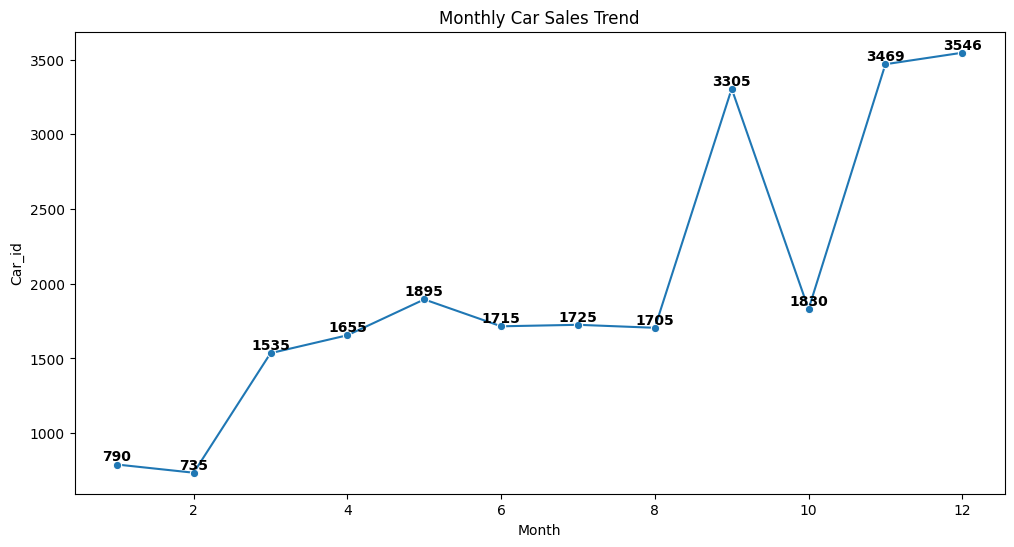

In [178]:
# Plotting the results using a line plot with markers and annotations
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Car_id', data=monthly_sales, marker='o', palette='viridis')

# # Annotate each marker with the numeric value
# for i in range(monthly_sales.shape[0]):
#     plt.text(monthly_sales['Month'][i], monthly_sales['Car_id'][i], str(monthly_sales['Car_id'][i]),
#              horizontalalignment='center', size='medium', color='black', weight='semibold')
for i in range(monthly_sales.shape[0]): plt.text(monthly_sales['Month'][i],
                                                 monthly_sales['Car_id'][i] + 25, str(monthly_sales['Car_id'][i]),
                                                 horizontalalignment='center', size='medium', color='black', weight='semibold')
plt.title('Monthly Car Sales Trend')
plt.xlabel
plt.show()

The data reveals distinct sales patterns throughout the year: lowest sales in early months (January-February) at around 315-320 units, followed by a spring increase to 705-800 units in March-April. Sales maintain a steady summer plateau (690-750 units), before showing a dramatic surge in Month 9 reaching 1,458 units, nearly double the previous month.

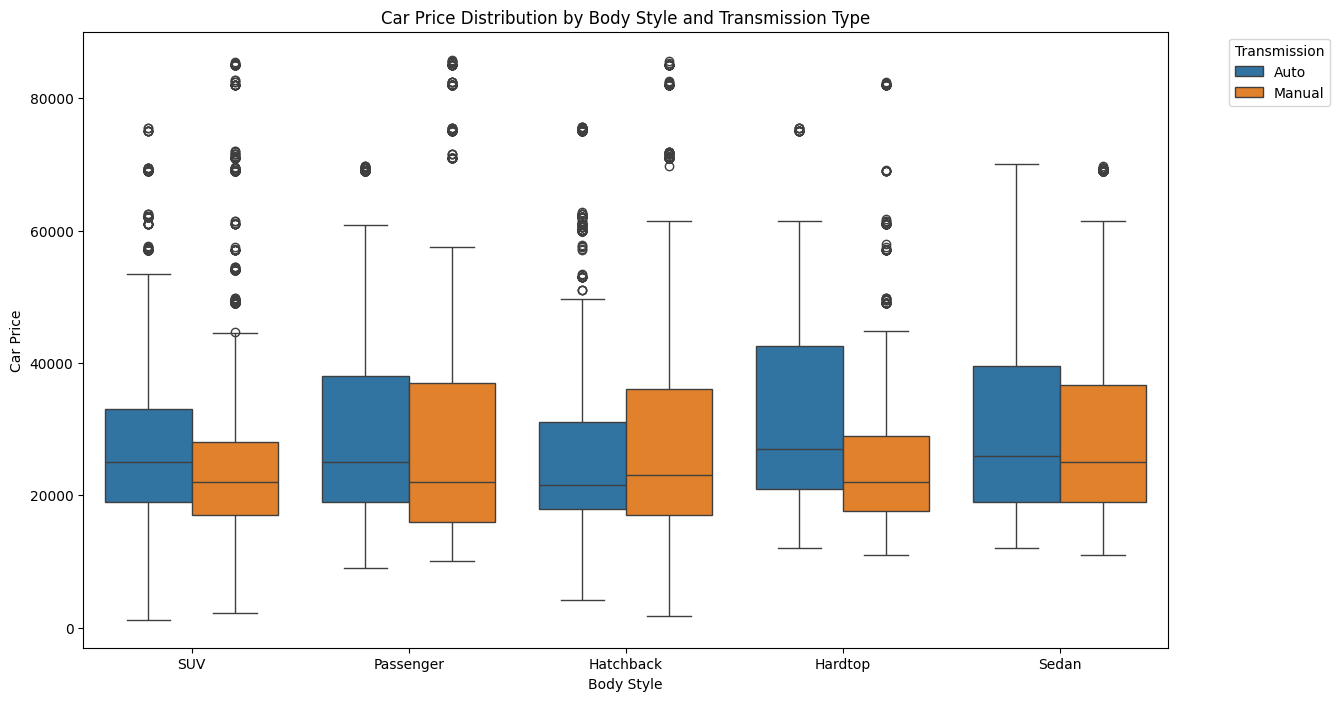

In [179]:
#Q13.How does the car price distribution change when considering different combinations of body style and transmission type

# Group by Body Style and Transmission to calculate average car price
avg_price_by_body_transmission = cs1.groupby(['Body_Style', 'Transmission'])['Price'].mean().reset_index()

# Plotting the price distribution using a box plot
plt.figure(figsize=(14, 8))
sns.boxplot(x='Body_Style', y='Price', hue='Transmission', data=cs1, palette='tab10')
plt.title('Car Price Distribution by Body Style and Transmission Type')
plt.xlabel('Body Style')
plt.ylabel('Car Price')
plt.legend(title='Transmission', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


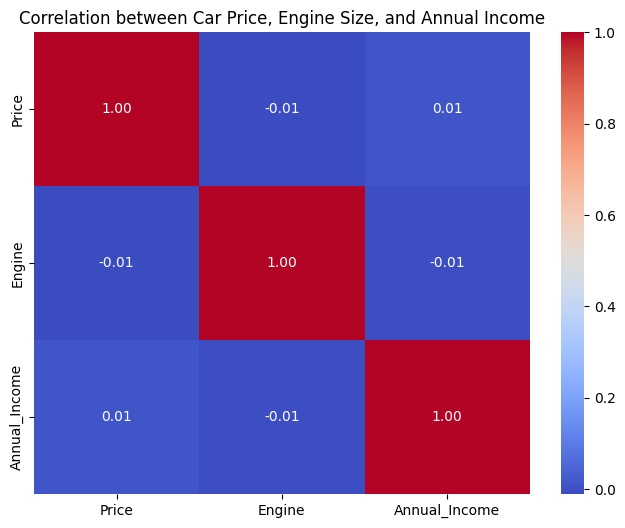

In [180]:
#Q14. What is the correlation between car price, engine size, and annual income of customers, and how do these features interact?

# Convert 'Engine' to a numerical format if it's categorical
cs2['Engine'] = cs2['Engine'].astype('category').cat.codes

# Calculate the correlation matrix
correlation_matrix = cs2[['Price', 'Engine', 'Annual_Income']].corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between Car Price, Engine Size, and Annual Income')
plt.show()


The heatmap shows virtually no correlation between car price, engine size, and annual income (correlation values near 0: -0.01 to 0.01). This suggests these variables are independent of each other, contrary to what might be expected.

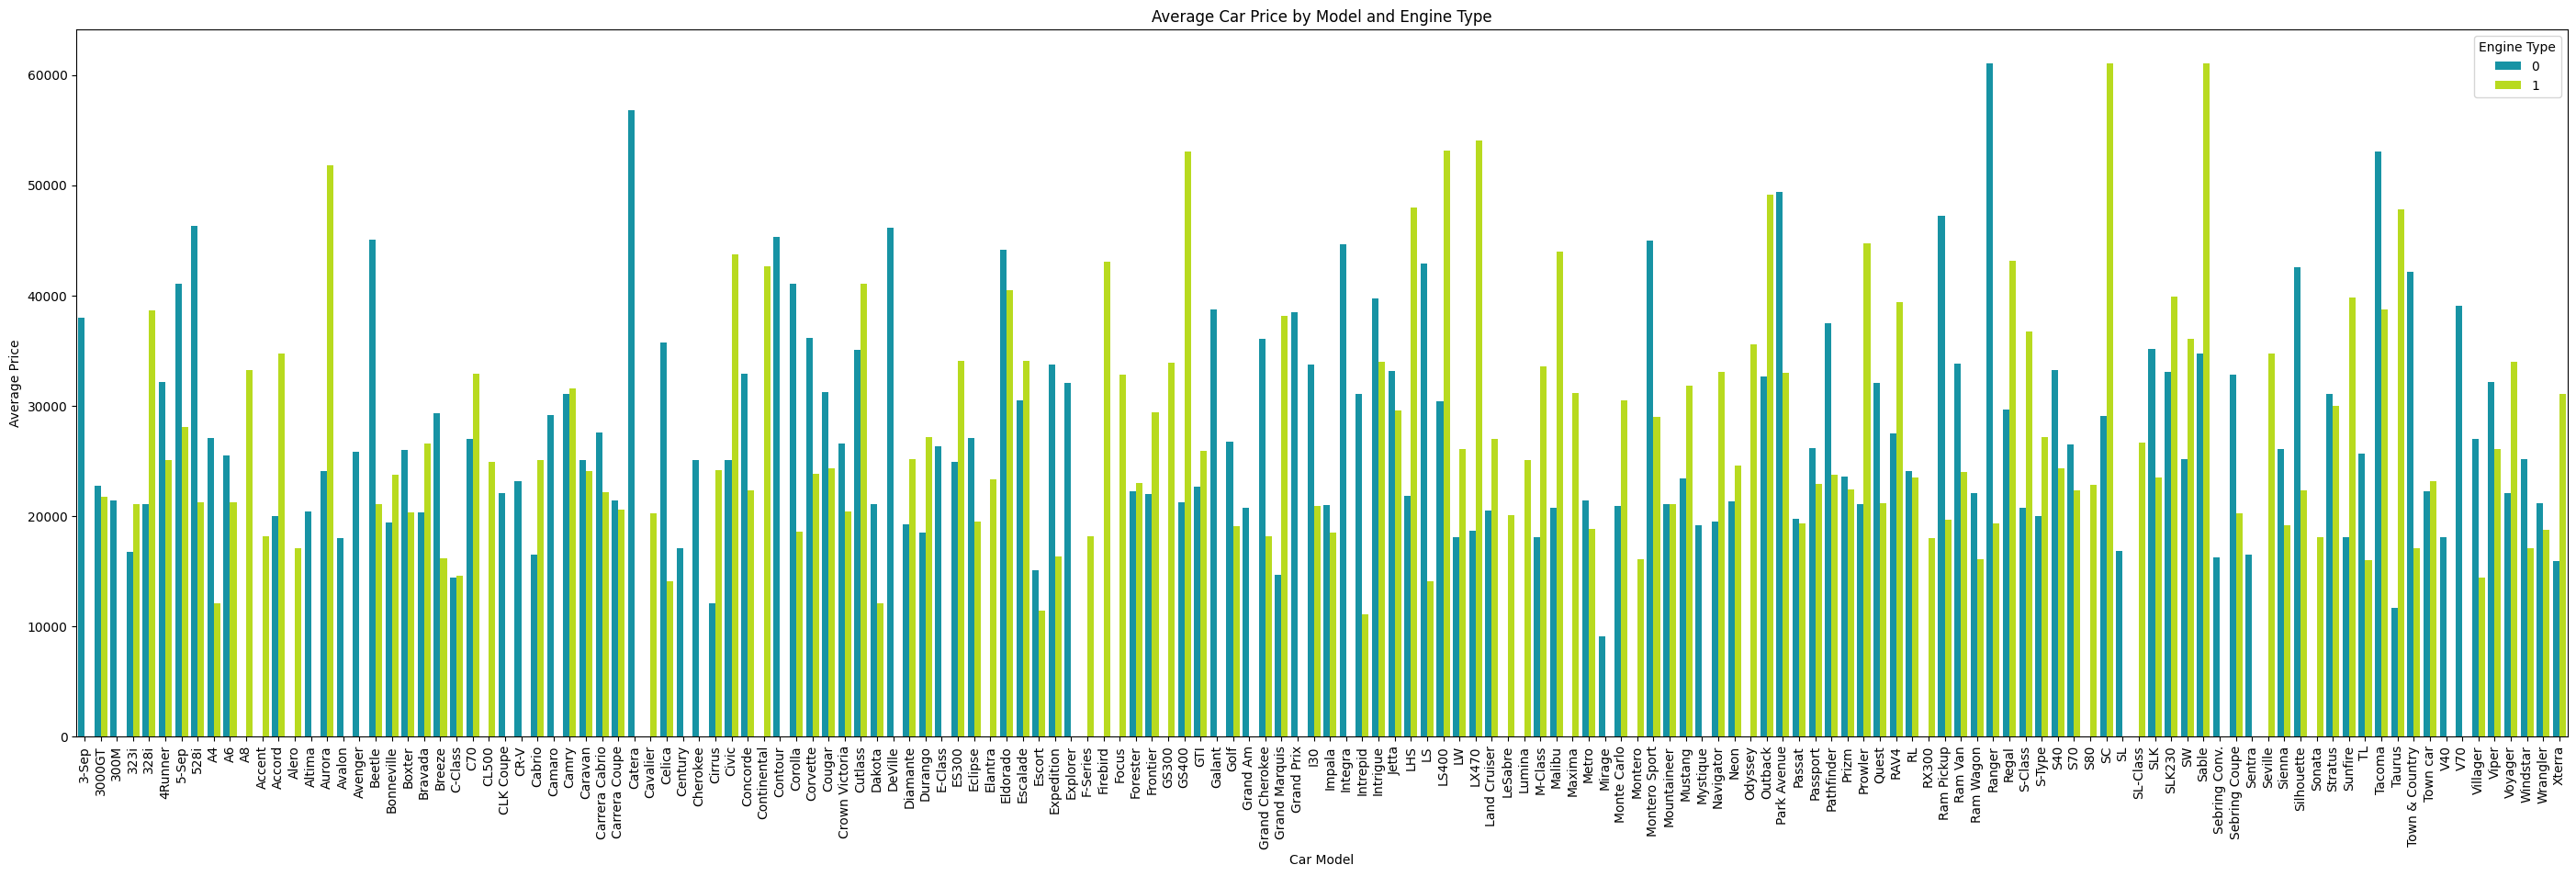

In [181]:
#Q15. How does the average car price vary across different car models and engine types?

# Calculate the average car price for each combination of car model and engine type
avg_price_by_model_engine = cs2.groupby(['Model', 'Engine'])['Price'].mean().reset_index()

# Visualize the results using a bar plot
plt.figure(figsize=(35, 10))
sns.barplot(x='Model', y='Price', hue='Engine', data=avg_price_by_model_engine, palette='nipy_spectral')
plt.title('Average Car Price by Model and Engine Type')
plt.xlabel('Car Model')
plt.ylabel('Average Price')
plt.xticks(rotation=90)
plt.legend(title='Engine Type')
plt.show()


The bar chart shows significant price variation across car models and engine types. Most models range between 20,000-40,000 price points, with some premium models reaching 60,000. Engine types (shown in green and blue) demonstrate varying price impacts across different models, but no consistent pattern of one engine type commanding higher prices.

# EDA - Amazon Sales

 This dataset contains information on 1K+ Amazon products, including their ratings, reviews, and other details.

 **Features:**

 - **product_id:** Unique identifier for each product
 - **product_name:** Name of the product
 - **category:** Category of the product
 - **discounted_price:** Discounted price of the product
 - **actual_price:** Actual price of the product
 - **discount_percentage:** Percentage of discount for the product
 - **rating:** Rating of the product (1-5)
 - **rating_count:** Number of people who voted for the Amazon rating
 - **about_product:** Description about the product
 - **user_id:** ID of the user who wrote the review
 - **user_name:** Name of the user who wrote the review
 - **review_id:** ID of the user review
 - **review_title:** Short review
 - **review_content:** Long review
 - **img_link:** Image link of the product
 - **product_link:** Official website link of the product

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [183]:
amazon_df = pd.read_csv("/content/amazon.csv")

In [184]:
amz = amazon_df.copy()

In [185]:
amz

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,₹379,₹919,59%,4,"1,090",SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,"AHITFY6AHALOFOHOZEOC6XBP4FEA,AFRABBODZJZQB6Z4U...","Prabha ds,Raghuram bk,Real Deal,Amazon Custome...","R3G3XFHPBFF0E8,R3C0BZCD32EIGW,R2EBVBCN9QPD9R,R...","Received the product without spanner,Excellent...","I received product without spanner,Excellent p...",https://m.media-amazon.com/images/I/41fDdRtjfx...,https://www.amazon.in/Noir-Aqua-Spanner-Purifi...
1461,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,"₹2,280","₹3,045",25%,4.1,"4,118","230 Volts, 400 watts, 1 Year","AFG5FM3NEMOL6BNFRV2NK5FNJCHQ,AGEINTRN6Z563RMLH...","Manu Bhai,Naveenpittu,Evatira Sangma,JAGANNADH...","R3DDL2UPKQ2CK9,R2SYYU1OATVIU5,R1VM993161IYRW,R...","ok,everything was good couldn't return bcoz I ...","ok,got everything as mentioned but the me

In [186]:
amz.shape

(1465, 16)

In [187]:
amz.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [188]:
amz.isnull().sum() #Check for Null Value

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,2
about_product,0
user_id,0


In [189]:
amz.dropna(inplace=True) #Dropping the Null Values

In [190]:
amz.duplicated().any()

False

In [191]:
amz.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1463 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1463 non-null   object
 1   product_name         1463 non-null   object
 2   category             1463 non-null   object
 3   discounted_price     1463 non-null   object
 4   actual_price         1463 non-null   object
 5   discount_percentage  1463 non-null   object
 6   rating               1463 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1463 non-null   object
 9   user_id              1463 non-null   object
 10  user_name            1463 non-null   object
 11  review_id            1463 non-null   object
 12  review_title         1463 non-null   object
 13  review_content       1463 non-null   object
 14  img_link             1463 non-null   object
 15  product_link         1463 non-null   object
dtypes: object(1

In [192]:
amz.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

In [193]:
amz1 = amz.copy()

In [194]:
# Drop the columns 'user_id', 'user_name', 'review_id', 'review_title', 'img_link', and 'product_link' from the DataFrame 'amz1'
# This is done to remove unnecessary or sensitive information from the dataset

amz1 = amz1.drop(columns=['user_id', 'user_name', 'review_id', 'review_title', 'img_link', 'product_link'], axis=1)

In [195]:
amz1.shape

(1463, 10)

In [196]:
amz1.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'review_content'],
      dtype='object')

In [197]:
# Check the unique values in the 'discounted_price' column
unique_discounted_price = amz1['discounted_price'].unique()
print("Unique values in 'discounted_price':", unique_discounted_price)

# Check the unique values in the 'actual_price' column
unique_actual_price = amz1['actual_price'].unique()
print("\nUnique values in 'actual_price':", unique_actual_price)

# Check the unique values in the 'discount_percentage' column
unique_discount_percentage = amz1['discount_percentage'].unique()
print("\nUnique values in 'discount_percentage':", unique_discount_percentage)

# Check the unique values in the 'rating_count' column
unique_rating_count = amz1['rating_count'].unique()
print("\nUnique values in 'rating_count':", unique_rating_count)

# Found out that 'discounted_price', 'actual_price', 'discount_percentage', and 'rating_count' had symbols that made them strings


Unique values in 'discounted_price': ['₹399' '₹199' '₹329' '₹154' '₹149' '₹176.63' '₹229' '₹499' '₹299' '₹219'
 '₹350' '₹159' '₹349' '₹13,999' '₹249' '₹13,490' '₹970' '₹279' '₹59'
 '₹11,499' '₹14,999' '₹179' '₹389' '₹599' '₹99' '₹899' '₹32,999' '₹209'
 '₹19,999' '₹999' '₹333' '₹507' '₹309' '₹1,199' '₹799' '₹6,999' '₹230'
 '₹649' '₹15,999' '₹348' '₹32,990' '₹139' '₹263' '₹7,999' '₹1,599'
 '₹26,999' '₹115' '₹10,901' '₹1,434' '₹7,299' '₹325' '₹29,999' '₹27,999'
 '₹30,990' '₹269' '₹24,999' '₹18,990' '₹290' '₹345' '₹1,099' '₹719' '₹849'
 '₹21,999' '₹449' '₹37,999' '₹7,390' '₹273.10' '₹15,990' '₹210' '₹1,299'
 '₹347' '₹228' '₹1,499' '₹8,499' '₹20,990' '₹9,999' '₹489' '₹23,999'
 '₹689' '₹1,699' '₹655' '₹749' '₹195' '₹416' '₹368' '₹29,990' '₹339'
 '₹15,490' '₹9,490' '₹637' '₹1,089' '₹12,499' '₹1,399' '₹88' '₹57.89'
 '₹205' '₹949' '₹379' '₹8,990' '₹486' '₹5,699' '₹709' '₹47,990' '₹320'
 '₹129' '₹225' '₹547' '₹259' '₹239' '₹467' '₹11,990' '₹252' '₹204'
 '₹6,490' '₹235' '₹42,999' '₹173' '₹848.99'

In [198]:
# Function to clean price and percentage columns
def clean_column(value):
  if isinstance(value, str):
    return pd.to_numeric(value.replace('₹', '').replace(',', '').replace('%', ''), errors='coerce')

# Apply the function to the relevant columns
amz1['discounted_price'] = amz1['discounted_price'].apply(clean_column)
amz1['actual_price'] = amz1['actual_price'].apply(clean_column)
amz1['discount_percentage'] = amz1['discount_percentage'].apply(clean_column)
amz1['rating_count'] = amz1['rating_count'].apply(clean_column)

In [199]:
amz1.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,review_content
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64,4.2,24269,High Compatibility : Compatible With iPhone 12...,Looks durable Charging is fine tooNo complains...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43,4.0,43994,"Compatible with all Type C enabled devices, be...",I ordered this cable to connect my phone to An...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90,3.9,7928,【 Fast Charger& Data Sync】-With built-in safet...,"Not quite durable and sturdy,https://m.media-a..."
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53,4.2,94363,The boAt Deuce USB 300 2 in 1 cable is compati...,"Good product,long wire,Charges good,Nice,I bou..."
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61,4.2,16905,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"Bought this instead of original apple, does th..."


In [200]:
amz1.dtypes

,0
product_id,object
product_name,object
category,object
discounted_price,float64
actual_price,float64
discount_percentage,int64
rating,object
rating_count,int64
about_product,object
review_content,object


In [201]:
amz1.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'review_content'],
      dtype='object')

In [202]:
amz1.rating.unique() # one row had '|' made rating column an object, so dropped it

array(['4.2', '4.0', '3.9', '4.1', '4.3', '4.4', '4.5', '3.7', '3.3',
       '3.6', '3.4', '3.8', '3.5', '4.6', '3.2', '5.0', '4.7', '3.0',
       '2.8', '4', '3.1', '4.8', '2.3', '|', '2', '3', '2.6', '2.9'],
      dtype=object)

In [203]:
amz1.rating_count.unique()

array([24269, 43994,  7928, ...,   468,  8031,  6987])

In [204]:
amz1[amz1['rating'] == '|']

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,review_content
1279,B08L12N5H1,Eureka Forbes car Vac 100 Watts Powerful Sucti...,"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cle...",2099.0,2499.0,16,|,992,No Installation is provided for this product|1...,"Does the job well,doesn't work on sand. though..."


In [205]:
amz1 = amz1[amz1['rating'] != '|']  #Dropping the row with the "|" symbol

In [206]:
amz1['rating'] = pd.to_numeric(amz1['rating'], errors='coerce')

In [207]:
amz1.reset_index(drop=True, inplace=True)

In [208]:
amz1 # Final

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,review_content
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64,4.2,24269,High Compatibility : Compatible With iPhone 12...,Looks durable Charging is fine tooNo complains...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43,4.0,43994,"Compatible with all Type C enabled devices, be...",I ordered this cable to connect my phone to An...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90,3.9,7928,【 Fast Charger& Data Sync】-With built-in safet...,"Not quite durable and sturdy,https://m.media-a..."
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53,4.2,94363,The boAt Deuce USB 300 2 in 1 cable is compati...,"Good product,long wire,Charges good,Nice,I bou..."
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61,4.2,16905,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"Bought this instead of original apple, does th..."
...,...,...,...,...,...,...,...,...,...,...
1457,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,379.0,919.0,59,4.0,1090,SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,"I received product without spanner,Excellent p..."
1458,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,2280.0,3045.0,25,4.1,4118,"230 Volts, 400 watts, 1 Year","ok,got everything as mentioned but the measuri..."
1459,B009P2LIL4,Bajaj Majesty RX10 2000 Watts Heat Convector R...,"Home&Kitchen|Heating,Cooling&AirQuality|RoomHe...",2219.0,3080.0,28,3.6,468,International design and styling|Two heat sett...,"plastic but cool body ,u have to find sturdy s..."
1460,B00J5DYCCA,Havells Ventil Air DSP 230mm Exhaust Fan (Pist...,"Home&Kitchen|Heating,Cooling&AirQuality|Fans|E...",1399.0,1890.0,26,4.0,8031,Fan sweep area: 230 MM ; Noise level: (40 - 45...,I have installed this in my kitchen working fi...


In [209]:
amz2 = amz1.copy()

In [210]:
# Split the category column into multiple columns
category_columns = amz2['category'].str.split('|', expand=True)

# Create dynamic column names based on the number of levels
category_columns.columns = [f'Category_Level_{i+1}' for i in range(category_columns.shape[1])]

# Concatenate the new columns with the original DataFrame
amz2 = pd.concat([amz2, category_columns], axis=1)

# Display the first few rows of the updated DataFrame
amz2.head()


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,review_content,Category_Level_1,Category_Level_2,Category_Level_3,Category_Level_4,Category_Level_5,Category_Level_6,Category_Level_7
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64,4.2,24269,High Compatibility : Compatible With iPhone 12...,Looks durable Charging is fine tooNo complains...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,None,None
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43,4.0,43994,"Compatible with all Type C enabled devices, be...",I ordered this cable to connect my phone to An...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,None,None
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90,3.9,7928,【 Fast Charger& Data Sync】-With built-in safet...,"Not quite durable and sturdy,https://m.media-a...",Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,None,None
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53,4.2,94363,The boAt Deuce USB 300 2 in 1 cable is compati...,"Good product,long wire,Charges good,Nice,I bou...",Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,None,None
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61,4.2,16905,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"Bought this instead of original apple, does th...",Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,None,None


In [211]:
amz2.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000
mean,3129.981826,5453.087743,47.672367,4.096717,18307.376881
std,6950.548042,10884.467444,21.613905,0.289497,42766.096572
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,325.000000,800.000000,32.000000,4.000000,1191.500000
50%,799.000000,1670.000000,50.000000,4.100000,5179.000000
75%,1999.000000,4321.250000,63.000000,4.300000,17342.250000
max,77990.000000,139900.000000,94.000000,5.000000,426973.000000


In [212]:
#Q1. What is the average rating for each product category?

# Calculate the average rating for each product category
avg_rating_by_category = amz2.groupby('category')['rating'].mean().reset_index()

# Display the results
avg_rating_by_category

,category,rating
0,Car&Motorbike|CarAccessories|InteriorAccessori...,3.800000
1,Computers&Accessories|Accessories&Peripherals|...,4.150000
2,Computers&Accessories|Accessories&Peripherals|...,3.500000
3,Computers&Accessories|Accessories&Peripherals|...,3.600000
4,Computers&Accessories|Accessories&Peripherals|...,4.050000
...,...,...
206,OfficeProducts|OfficePaperProducts|Paper|Stati...,4.250000
207,OfficeProducts|OfficePaperProducts|Paper|Stati...,4.150000
208,OfficeProducts|OfficePaperProducts|Paper|Stati...,4.300000
209,OfficeProducts|OfficePaperProducts|Paper|Stati...,4.133333


In [213]:
#Q2. What are the top rating_count products by category

# Sort the DataFrame by rating_count in descending order
sorted_df = amz2.sort_values(by='rating_count', ascending=False)

# Drop duplicates to get the top-rated product for each category
top_rating_count_by_category1 = sorted_df.drop_duplicates(subset=['Category_Level_1'], keep='first')
#The reason we need to drop duplicates in this context is to ensure that we identify the top-rated product within each category based on rating_count

# Display the results
top_rating_count_by_category1[['Category_Level_1', 'product_name', 'rating_count']]

,Category_Level_1,product_name,rating_count
12,Electronics,AmazonBasics Flexible Premium HDMI Cable (Blac...,426973
1026,Home&Kitchen,Pigeon Polypropylene Mini Handy and Compact Ch...,270563
586,Computers&Accessories,SanDisk Cruzer Blade 32GB USB Flash Drive,253105
611,MusicalInstruments,Boya ByM1 Auxiliary Omnidirectional Lavalier C...,68664
922,Toys&Games,Faber-Castell Connector Pen Set - Pack of 25 (...,15867
657,OfficeProducts,Casio FX-82MS 2nd Gen Non-Programmable Scienti...,12179
980,HomeImprovement,"Gizga Essentials Cable Organiser, Cord Managem...",5985
1245,Health&PersonalCare,Dr Trust Electronic Kitchen Digital Scale Weig...,3663
1155,Car&Motorbike,Reffair AX30 [MAX] Portable Air Purifier for C...,1118


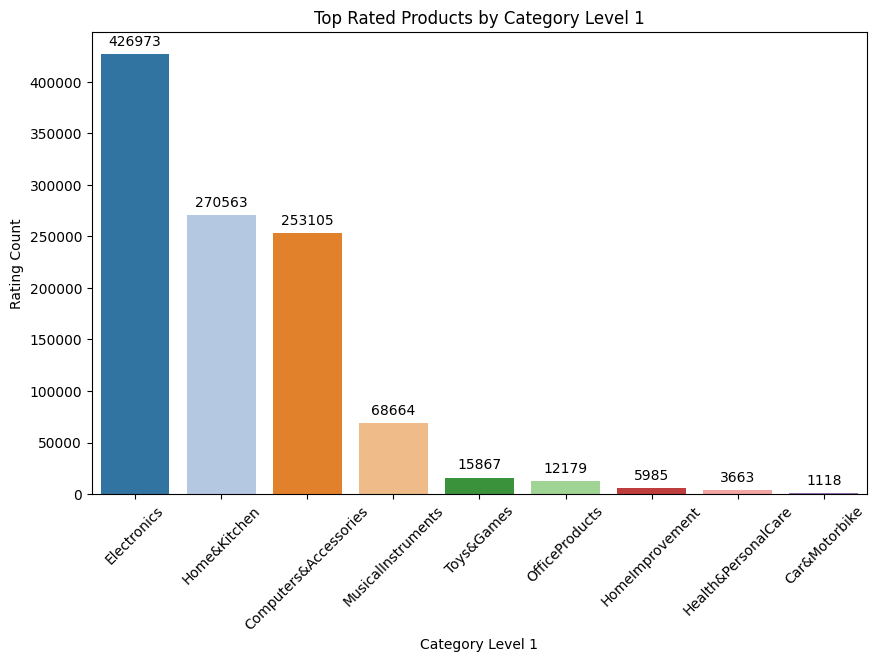

In [214]:
# Plotting the results using a bar chart
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='Category_Level_1', y='rating_count', data=top_rating_count_by_category1, palette='tab20')

# Annotate each bar with the numeric value
# Add the average price above each bar
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.0f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points')
plt.title('Top Rated Products by Category Level 1')
plt.xlabel('Category Level 1')
plt.ylabel('Rating Count')
plt.xticks(rotation=45)
plt.show()


Electronics leads by far with 426,973 ratings, which is nearly 1.6 times higher than the second-highest category, Home & Kitchen (270,563) and Computer Accessories (253,105). These top 3 categories dominate the ratings landscape, while other categories like Musical Instruments and Toys & Games show significantly lower engagement with less than 70,000 ratings each. The bottom categories (Cars & Motorbike, Health & Personal Care, Home Improvement) receive minimal ratings, all under 6,000, suggesting either lower sales volumes or reduced customer review participation in these segments.

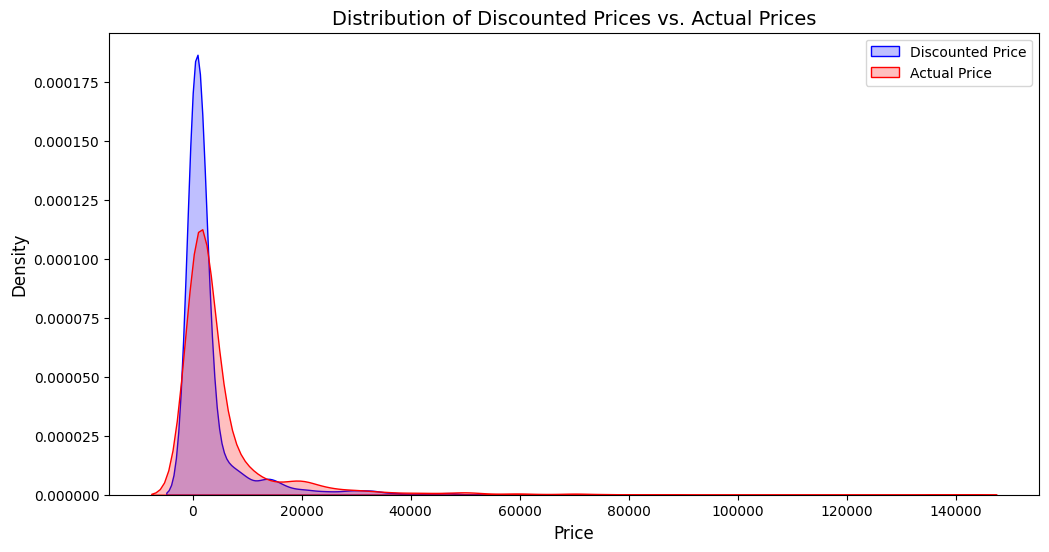

In [215]:
#Q3. What is the distribution of discounted prices vs. actual prices

plt.figure(figsize=(12, 6))
sns.kdeplot(amz2['discounted_price'], color='blue', label='Discounted Price', fill=True)
sns.kdeplot(amz2['actual_price'], color='red', label='Actual Price', fill=True)

# Adding title and labels
plt.title('Distribution of Discounted Prices vs. Actual Prices', fontsize=14)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()

# Observe 1: The blue curve (discounted price) being higher than the red curve (actual price) in certain areas does not mean the discounted price is
# higher than the actual price, it mmeans more products have discounted prices in that range compared to actual prices.

Most products are priced in the lower range, with discounted prices slightly lower than actual prices, as shown by the density plot's peaks. This indicates a high concentration of discounts in affordable price brackets. However, both distributions show a long tail, suggesting the presence of high-priced items, though these are less frequent. The data confirms that discounts are primarily targeted at lower-priced products, making them more appealing to budget-conscious buyers.

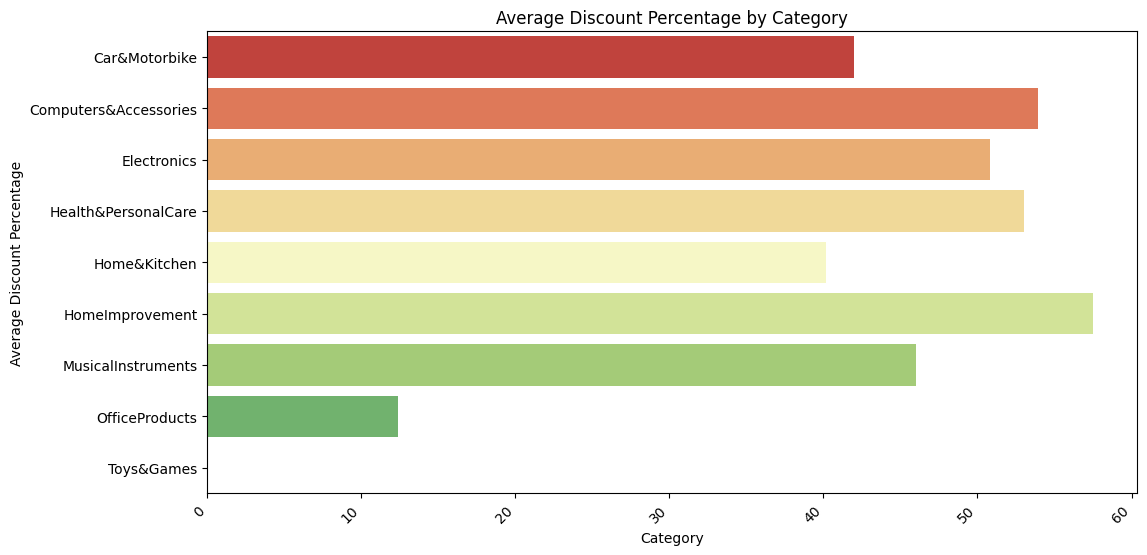

In [248]:
#Q4. How does the average discount percentage vary across categories?

# Calculate the average discount percentage for each category
avg_discount_by_category = amz2.groupby('Category_Level_1')['discount_percentage'].mean().reset_index()

# Create a bar plot using Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='discount_percentage', y='Category_Level_1', data=avg_discount_by_category, palette='RdYlGn')
plt.title('Average Discount Percentage by Category')
plt.xlabel('Category')
plt.ylabel('Average Discount Percentage')
plt.xticks(rotation=45, ha='right')
plt.show()


Home Improvement leads with the highest discounts at nearly 60%, followed closely by Computers & Accessories and Health & Personal Care, both offering around 50-55% discounts. Electronics and Musical Instruments show moderate discounts in the 45-50% range. At the lower end, Office Products offers minimal discounts around 12%, while Toys & Games shows the lowest discount percentage. This suggests significantly different pricing and promotional strategies across product categories, with home-related and tech products generally offering more aggressive discounts compared to toys and office supplies.

In [217]:
#Q5. What are the most popular product names?

# Count the occurrences of each product name
popular_product_names = amz2['product_name'].value_counts().reset_index()
popular_product_names.columns = ['product_name', 'count']

# Display the top 10 most popular product names
popular_product_names.head(10)


,product_name,count
0,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",5
1,Fire-Boltt Phoenix Smart Watch with Bluetooth ...,4
2,Wayona Nylon Braided USB to Lightning Fast Cha...,3
3,MI Braided USB Type-C Cable for Charging Adapt...,3
4,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,3
5,Amazonbasics Nylon Braided Usb-C To Lightning ...,3
6,"Fire-Boltt Visionary 1.78"" AMOLED Bluetooth Ca...",3
7,boAt A400 USB Type-C to USB-A 2.0 Male Data Ca...,3
8,Duracell USB C To Lightning Apple Certified (M...,3
9,Ambrane 60W / 3A Fast Charging Output Cable wi...,3


In [218]:
amz3 = amz2.copy()

In [219]:
#Q6. What are the most popular product keywords?

# Function to extract keywords from product names
def extract_keywords(product_name):
    # Convert to lowercase and split by spaces
    keywords = product_name.lower().split()
    keywords = [word for word in keywords if word.isalpha()]  # Remove non-alphabetical characters
    return keywords

# Extract keywords from all product names
amz3['keywords'] = amz3['product_name'].apply(extract_keywords)

# Flatten the list of keywords and create a DataFrame
all_keywords = [keyword for sublist in amz3['keywords'] for keyword in sublist]
keywords_df = pd.DataFrame(all_keywords, columns=['keyword'])

# Count the occurrences of each keyword
popular_keywords = keywords_df['keyword'].value_counts().reset_index()
popular_keywords.columns = ['keyword', 'count']

# Display the top 10 most popular keywords
print("Most Popular Product Keywords:")
print(popular_keywords.head(10))


Most Popular Product Keywords:
    keyword  count
0      with    749
1       for    671
2       usb    377
3       and    329
4     cable    318
5  charging    217
6        to    214
7      fast    209
8         c    179
9     smart    171


The most popular product keywords indicate a strong focus on connectivity, charging (especially fast charging), and cables. Words like "USB," "cable," "charging," and "smart" suggest high demand for tech accessories. Additionally, frequent use of words like "with," "for," and "to" highlights how product names emphasize compatibility and usage scenarios. The dataset likely contains a significant number of cables and smart devices, and refining keyword extraction could further improve insights into product trends.

In [220]:
amz.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

In [221]:
#Q7.  What are the most popular product reviews?

# Count the occurrences of each review content
popular_reviews = amz['review_content'].value_counts().reset_index()
popular_reviews.columns = ['review_content', 'count']

# Display the top 10 most popular product reviews
print("Most Popular Product Reviews:")
popular_reviews.head(10)


Most Popular Product Reviews:


,review_content,count
0,"I am not big on camera usage, personally. I wa...",8
1,I ordered this cable to connect my phone to An...,7
2,"Good product,long wire,Charges good,Nice,I bou...",7
3,Worked on iPhone 7 and didn’t work on iPhone X...,7
4,128GB SD Card is showing 134GBDon't buy this p...,6
5,I purchased the 6/128gb variant.To sum it up ...,6
6,[Update: Sept 29] boAt seems to have heard the...,5
7,"I liked it, worth the money, light weight and ...",5
8,About the TV - Wonderful----------------------...,5
9,Good budget mfi certified lightly cable for th...,5


In [222]:
#Q8.  What is the correlation between discounted_price and rating?

# Calculate the Pearson correlation coefficient
correlation = amz2['discounted_price'].corr(amz2['rating'])

# Display the correlation
print("Correlation between discounted_price and rating:", correlation)


Correlation between discounted_price and rating: 0.12113187526066266


Discounted price and rating have a weak positive correlation. This means that products with higher discounted prices tend to have slightly higher ratings, but the relationship is not very strong.

In [223]:
#Q9.  What are the Top 5 categories based on the highest ratings?

# Calculate the average rating for each Category_Level_1
avg_rating_by_category = amz2.groupby('Category_Level_1')['rating'].mean().reset_index()

# Sort the categories by average rating in descending order
top_categories = avg_rating_by_category.sort_values(by='rating', ascending=False).head(5)
top_categories_sorted = top_categories.reset_index(drop=True)

# Display the top 5 categories
print(top_categories_sorted)


        Category_Level_1    rating
0         OfficeProducts  4.309677
1             Toys&Games  4.300000
2        HomeImprovement  4.250000
3  Computers&Accessories  4.155654
4            Electronics  4.081749


The top-rated categories based on average ratings are Office Products, Toys & Games, Home Improvement, Computers & Accessories, and Electronics.

Office Products (4.31) and Toys & Games (4.30) have the highest ratings, suggesting strong customer satisfaction, possibly due to reliability and usability.
Home Improvement (4.25) also ranks high, indicating that customers are generally pleased with the quality of tools and materials.
Computers & Accessories (4.16) and Electronics (4.08), while slightly lower, still maintain strong ratings, reflecting positive user experiences with gadgets and tech-related products.
Overall, these categories are well-received, potentially due to product quality, usability, or customer support.

**Q10. Identify any potential areas for improvement or optimization based on the data analysis.**

**Ans:** Based on the data analysis, several areas for improvement and optimization emerge:

 **Underperforming Categories:**

Certain categories, such as Cars & Motorbike, Health & Personal Care, and Home Improvement, show low engagement despite offering substantial discounts. This suggests potential issues with product selection, marketing reach, or customer awareness. Office Products and Toys & Games also exhibit minimal discounts and low ratings, indicating an opportunity for targeted marketing and revised pricing strategies.

**Pricing and Discount Strategy**

Home Improvement has the highest discounts (~60%) but low rating counts, indicating that steep discounts are not effectively driving engagement. Electronics, on the other hand, maintains high engagement despite moderate discounts, suggesting room for further optimization in discount levels. Balancing discount strategies with customer engagement metrics can help identify optimal price points for different categories.

**Customer Engagement & Review Optimization**

Categories like Musical Instruments and Health & Personal Care have decent discounts but low rating counts. Encouraging customers to leave reviews through follow-up emails, loyalty programs, or incentives could improve engagement. Implementing category-specific review solicitation strategies may also help boost participation. Leveraging successful categories such as Electronics and Home & Kitchen can provide insights into best practices.

**Strategic Recommendations**

To maximize growth and profitability, businesses should:

- Reassess discounting strategies in categories with high discounts but low engagement.
- Develop targeted marketing campaigns for underperforming categories.
- Implement customer feedback programs in low-rating categories to better understand customer preferences and engagement barriers.
- By focusing on these areas, businesses can enhance customer satisfaction, optimize sales performance, and refine their overall marketing and pricing strategies.

# EDA - Spotify

 The dataset titled "Spotify Data: Popular Hip-hop Artists and Tracks" provides a curated collection of
approximately 500 entries showcasing the vibrant realm of hip-hop music. These entries meticulously compile
the most celebrated hip-hop tracks and artists, reflecting their significant influence on the genre's landscape.
Each entry not only highlights the popularity and musical composition of the tracks but also underscores the
creative prowess of the artists and their profound impact on global listeners.

**Features:**

 - **Artist:** The name of the artist, providing direct attribution to the creative mind behind the track.
 - **Track Name:** The title of the track, encapsulating its identity and essence.
 - **Popularity:** A numeric score reflecting the track's reception and appeal among Spotify listeners.
 - **Duration (ms):** The track's length in milliseconds, detailing the temporal extent of the musical experience.
 - **Track ID:** A unique identifier within Spotify's ecosystem, enabling direct access to the track for further
exploration.

In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

In [225]:
#Q1.Read the dataframe, check null value if present then do the needful, check duplicate row , if present then do the needful.

spotify_df = pd.read_csv("/content/spotify.csv")

In [226]:
spot = spotify_df.copy()

In [227]:
spot.head()

,Artist,Track Name,Popularity,Duration (ms),Track ID
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA),92,319191,1yeB8MUNeLo9Ek1UEpsyz6
1,Drake,One Dance,91,173986,1zi7xx7UVEFkmKfv06H8x0
2,Drake,IDGAF (feat. Yeat),90,260111,2YSzYUF3jWqb9YP9VXmpjE
3,Drake,First Person Shooter (feat. J. Cole),88,247444,7aqfrAY2p9BUSiupwk3svU
4,Drake,Jimmy Cooks (feat. 21 Savage),88,218364,3F5CgOj3wFlRv51JsHbxhe


In [228]:
spot.shape

(440, 5)

In [229]:
spot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Artist         440 non-null    object
 1   Track Name     440 non-null    object
 2   Popularity     440 non-null    int64 
 3   Duration (ms)  440 non-null    int64 
 4   Track ID       440 non-null    object
dtypes: int64(2), object(3)
memory usage: 17.3+ KB


In [230]:
spot.isnull().sum()

,0
Artist,0
Track Name,0
Popularity,0
Duration (ms),0
Track ID,0


In [231]:
spot.duplicated().sum()

27

In [232]:
spot = spot.drop_duplicates()

In [233]:
spot.reset_index(drop= True, inplace=True)

In [234]:
spot.sample(2)

,Artist,Track Name,Popularity,Duration (ms),Track ID
19,Noah Kahan,Dial Drunk (with Post Malone),68,213817,5TXbpmu45IS8x0YPiUF1jy
171,Young Thug,Oh U Went (feat. Drake),76,185333,7qLr3HMApUbyDkUvgIvHnB


In [235]:
# Convert the duration from milliseconds to minutes
spot['duration_mins'] = round((spot['Duration (ms)'] / 60000),2)
spot.head()

,Artist,Track Name,Popularity,Duration (ms),Track ID,duration_mins
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA),92,319191,1yeB8MUNeLo9Ek1UEpsyz6,5.32
1,Drake,One Dance,91,173986,1zi7xx7UVEFkmKfv06H8x0,2.90
2,Drake,IDGAF (feat. Yeat),90,260111,2YSzYUF3jWqb9YP9VXmpjE,4.34
3,Drake,First Person Shooter (feat. J. Cole),88,247444,7aqfrAY2p9BUSiupwk3svU,4.12
4,Drake,Jimmy Cooks (feat. 21 Savage),88,218364,3F5CgOj3wFlRv51JsHbxhe,3.64


In [236]:
spot.dtypes

,0
Artist,object
Track Name,object
Popularity,int64
Duration (ms),int64
Track ID,object
duration_mins,float64


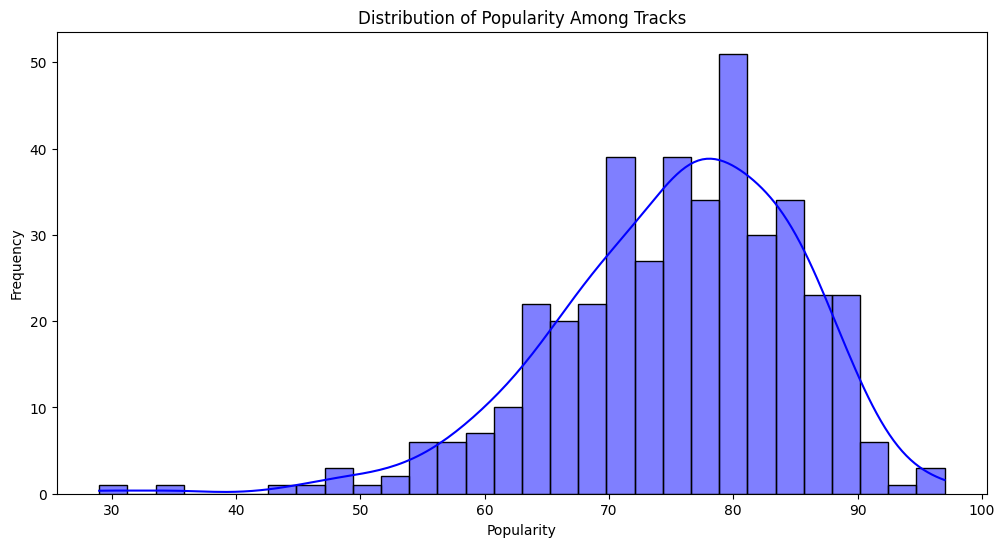

In [237]:
#Q2. What is the distribution of popularity among the tracks in the dataset? Visualize it using a histogram.

# Plotting the distribution of popularity using a histogram
plt.figure(figsize=(12, 6))
sns.histplot(spot['Popularity'], bins=30, kde=True, color='blue')
plt.title('Distribution of Popularity Among Tracks')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.show()


Looking at the Spotify track popularity distribution, most songs cluster in the high-popularity range of 70-90, with the peak around 80 points having about 50 tracks. There are very few songs with low popularity scores (below 50) or extremely high scores (above 95). This suggests the dataset primarily contains mainstream, well-performing tracks rather than lesser-known songs, showing a bias towards popular music in the collection.

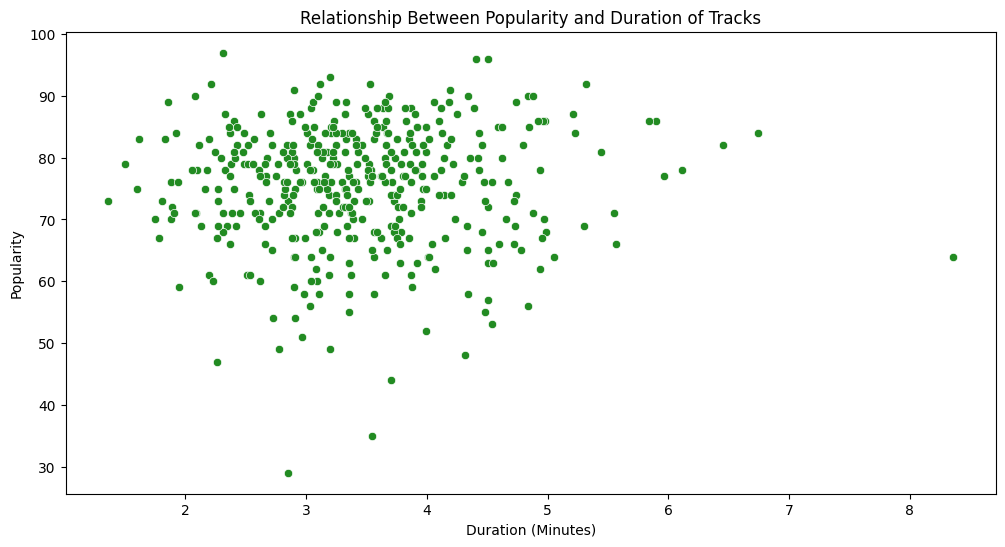

In [238]:
# Q3. Is there any relationship between the popularity and the duration of tracks? Explore this using a scatter plot

# Plotting the scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(x='duration_mins', y='Popularity', data=spot, color='forestgreen')
plt.title('Relationship Between Popularity and Duration of Tracks')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Popularity')
plt.show()


Looking at the relationship between track duration and popularity on Spotify, most popular tracks (scoring 60-90) cluster between 2-5 minutes in length, with the highest concentration around 3-4 minutes. There's no strong correlation between song length and popularity, meaning longer songs aren't necessarily more or less popular. However, very long songs (>6 minutes) and very short songs (<2 minutes) are rare in the dataset, suggesting that most successful tracks follow a standard radio-friendly format.

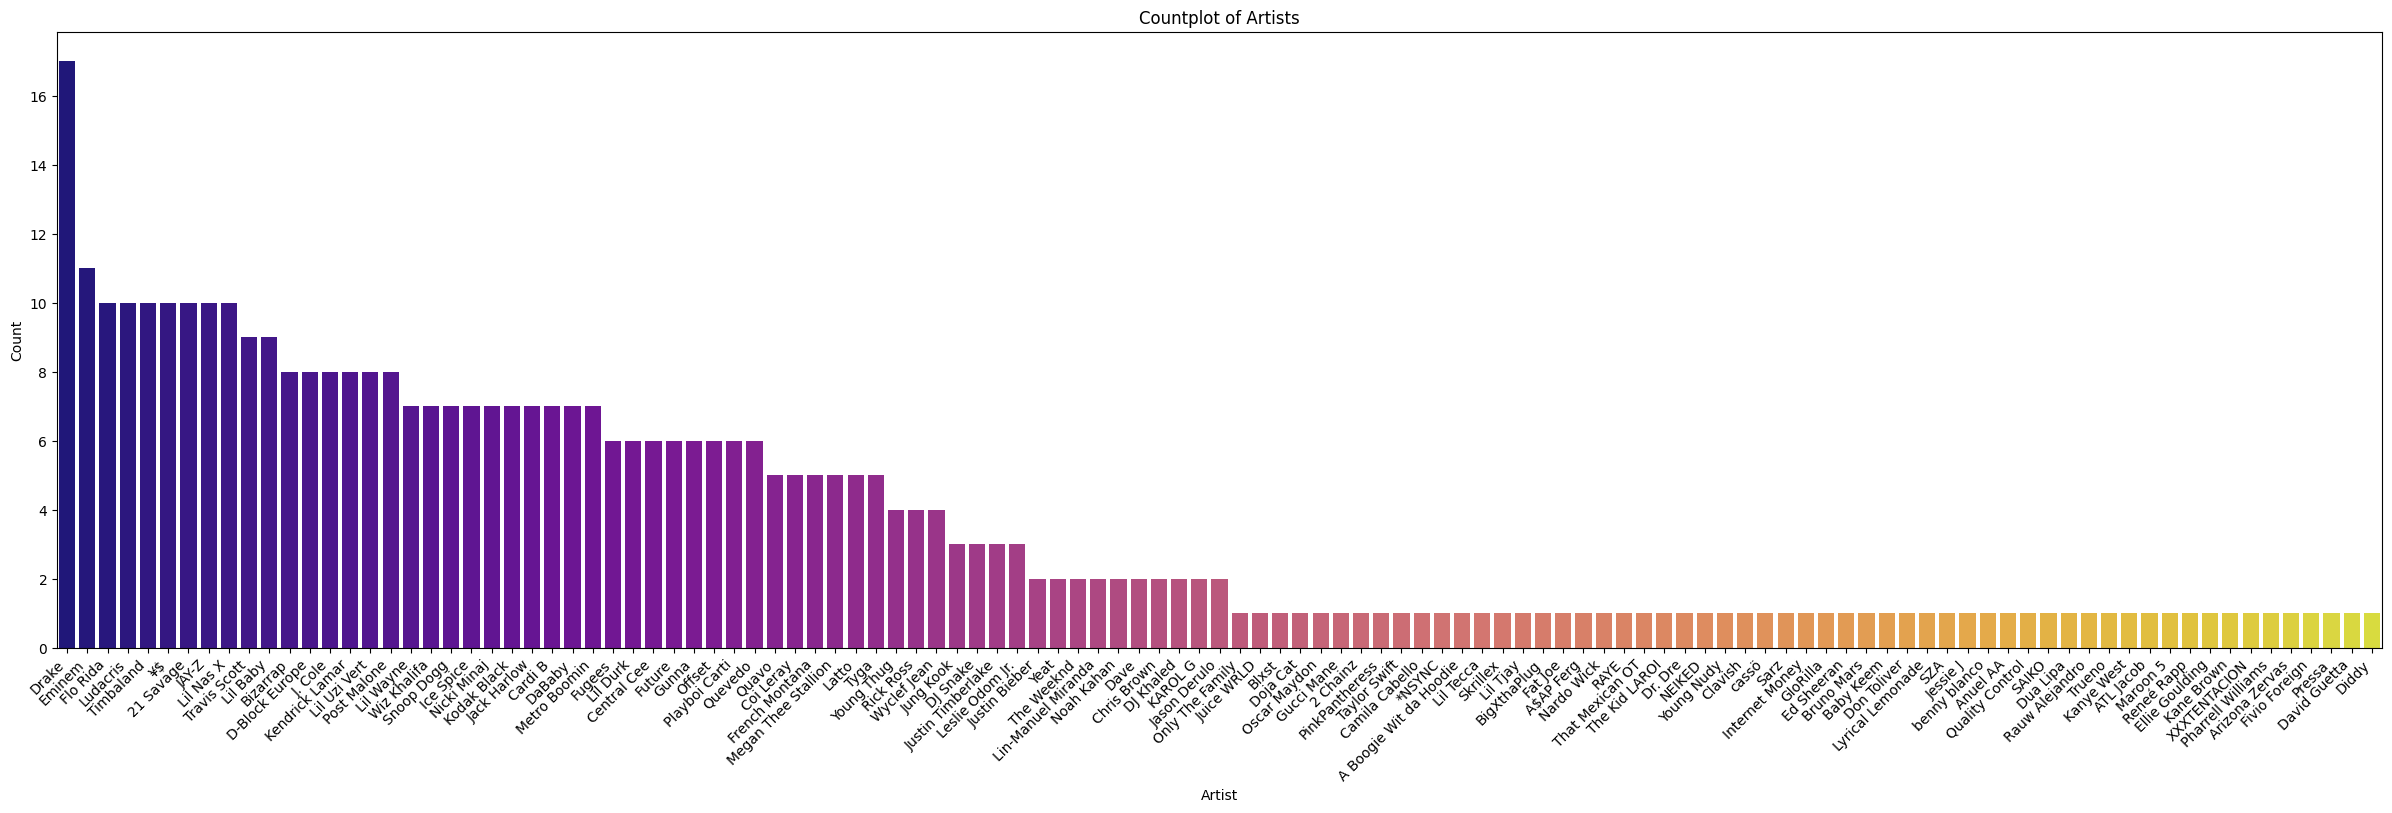

Artist with the highest number of tracks: Drake with 17 tracks


In [239]:
#Q4. Which artist has the highest number of tracks in the dataset? Display the count of tracks for each artist using a countplot.

# Count the occurrences of each artist name
artist_track_counts = spot['Artist'].value_counts().reset_index()
artist_track_counts.columns = ['Artist', 'count']

# Create a countplot using Seaborn
plt.figure(figsize=(30, 8))
sns.countplot(x='Artist', data=spot, order=spot['Artist'].value_counts().index, palette='plasma')
plt.title('Countplot of Artists')
plt.xlabel('Artist')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

# Display the artist with the highest number of tracks
most_tracks_artist = artist_track_counts.iloc[0]
print(f"Artist with the highest number of tracks: {most_tracks_artist['Artist']} with {most_tracks_artist['count']} tracks")



In [240]:
# Display the artist with the highest number of tracks
most_tracks_artist = artist_track_counts.iloc[0]
print(f"Artist with the highest number of tracks: {most_tracks_artist['Artist']} with {most_tracks_artist['count']} tracks")


Artist with the highest number of tracks: Drake with 17 tracks


In [241]:
#Q5.  What are the top 5 least popular tracks in the dataset? Provide the artist name and track name for each.

# Sort the DataFrame by popularity in ascending order
least_popular_tracks = spot.sort_values(by='Popularity', ascending=True).head(5)

# Display the artist name and track name for the top 5 least popular tracks
print("Top 5 Least Popular Tracks:")
least_popular_tracks[['Artist', 'Track Name', 'Popularity']]

Top 5 Least Popular Tracks:


,Artist,Track Name,Popularity
199,Pressa,Attachments (feat. Coi Leray),29
219,Justin Bieber,Intentions,35
390,French Montana,Splash Brothers,44
213,Lil Baby,On Me - Remix,47
384,Wyclef Jean,911 (feat. Mary J. Blige),48


In [242]:
#Q6.  What are the top 5 least popular tracks in the dataset? Provide the artist name and track name for each

# Count the occurrences of each artist name to find the top 5 most popular artists
top_artists = spot['Artist'].value_counts().head(5).index

# Filter the DataFrame to include only the top 5 most popular artists
top_artists_df = spot[spot['Artist'].isin(top_artists)]

# Calculate the average popularity for each of the top 5 artists
avg_popularity_by_artist = top_artists_df.groupby('Artist')['Popularity'].mean().reset_index()

# Sort the artists by average popularity in descending order
avg_popularity_by_artist = avg_popularity_by_artist.sort_values(by='Popularity', ascending=False).reset_index(drop=True)

# Display the average popularity for each artist
print("Average Popularity for Top 5 Most Popular Artists:\n")
print((avg_popularity_by_artist))

# Identify the artist with the highest average popularity
most_popular_artist = avg_popularity_by_artist.iloc[0]


Average Popularity for Top 5 Most Popular Artists:

      Artist  Popularity
0     Eminem   83.636364
1      Drake   82.882353
2   Flo Rida   78.000000
3  Timbaland   69.000000
4   Ludacris   63.000000


 Artist with the highest average popularity: **Eminem** with an average popularity of **83.64**

In [243]:
spot.columns

Index(['Artist', 'Track Name', 'Popularity', 'Duration (ms)', 'Track ID',
       'duration_mins'],
      dtype='object')

In [244]:
#Q7.  For the top 5 most popular artists, what are their most popular tracks? List the track name for each artist

# Count the occurrences of each artist name to find the top 5 most popular artists
top_artists = spot['Artist'].value_counts().head(5).index

# Filter the DataFrame to include only the top 5 most popular artists
top_artists_df = spot[spot['Artist'].isin(top_artists)]

# Find the most popular track for each of the top 5 artists
most_popular_tracks = top_artists_df.loc[top_artists_df.groupby('Artist')['Popularity'].idxmax()]

# Display the artist name and track name for the most popular tracks
print("Most Popular Tracks for Top 5 Most Popular Artists:")
print(most_popular_tracks[['Artist', 'Track Name', 'Popularity']])


Most Popular Tracks for Top 5 Most Popular Artists:
        Artist                               Track Name  Popularity
0        Drake  Rich Baby Daddy (feat. Sexyy Red & SZA)          92
75      Eminem                               Without Me          90
282   Flo Rida                       Low (feat. T-Pain)          84
348   Ludacris                             My Chick Bad          67
357  Timbaland                            The Way I Are          85


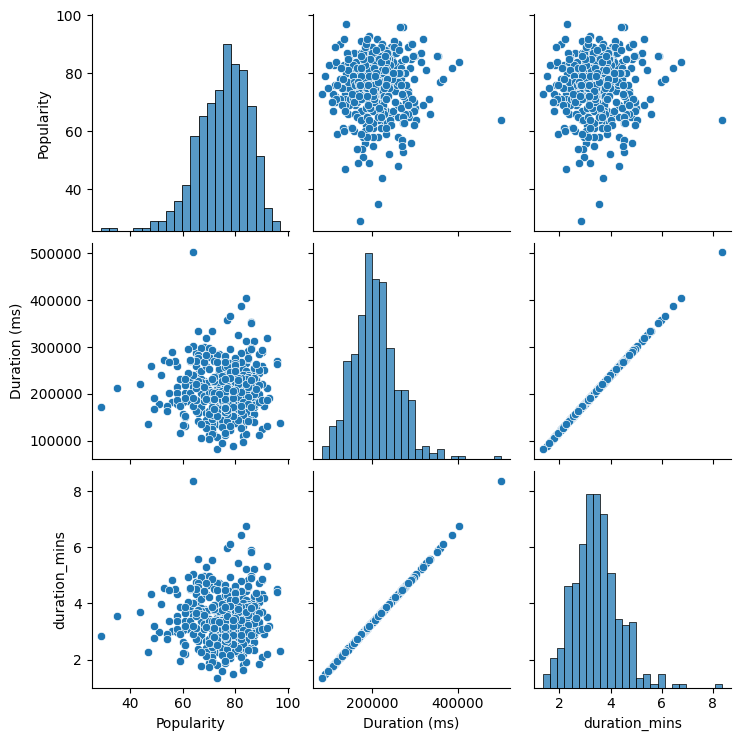

In [245]:
#Q8. Visualize relationships between multiple numerical variables simultaneously using a pair plot

# Create a pair plot using Seaborn
sns.pairplot(spot)
plt.show()

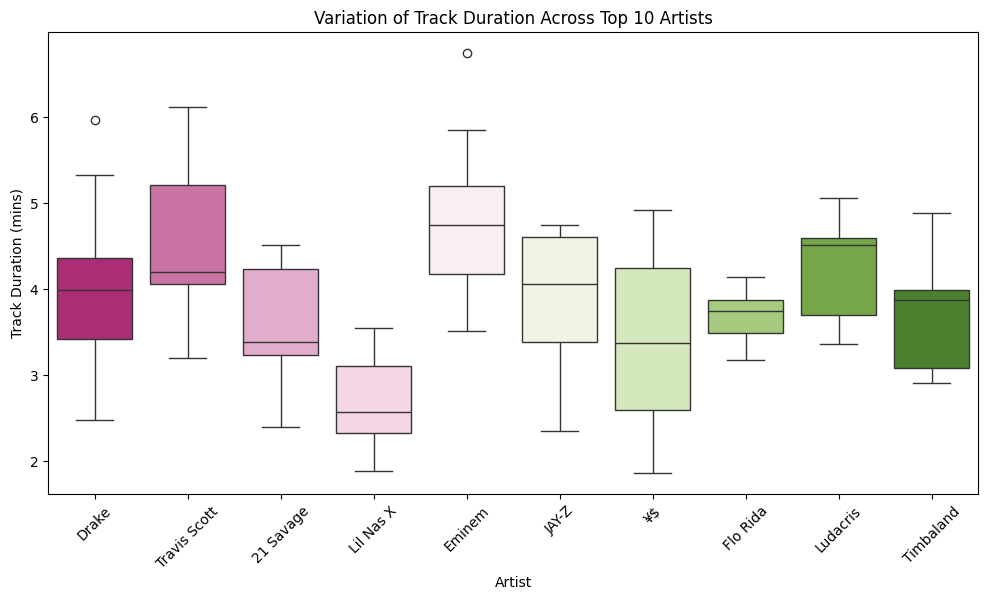

In [246]:
#Q9. Does the duration of tracks vary significantly across different artists? Explore this visually using a box plot or violin plot

# Instead of plotting all 115 artists, filter the top 10-15 based on:

# Most popular artists (sort by avg. popularity)
# Artists with the most tracks in the dataset
# Artists with the highest variance in track duration

# Get top 10 artists with most songs
top_artists = spot['Artist'].value_counts().head(10).index
df_top = spot[spot['Artist'].isin(top_artists)]

# Plot box plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top, x='Artist', y='duration_mins', palette="PiYG")
plt.xticks(rotation=45)
plt.xlabel("Artist")
plt.ylabel("Track Duration (mins)")
plt.title("Variation of Track Duration Across Top 10 Artists")
plt.show()


Analyzing track duration across the top 10 artists reveals significant variations in song length preferences. Eminem shows the highest median duration (around 4.8 minutes) with the widest range, while Lil Nas X tends toward shorter tracks (median around 2.5 minutes) with less variation. Most artists maintain their track lengths between 3-5 minutes, with occasional outliers exceeding 6 minutes. Artists like Travis Scott, Drake, and Ludacris show moderate variation in their track durations, suggesting consistent song length patterns in their music.

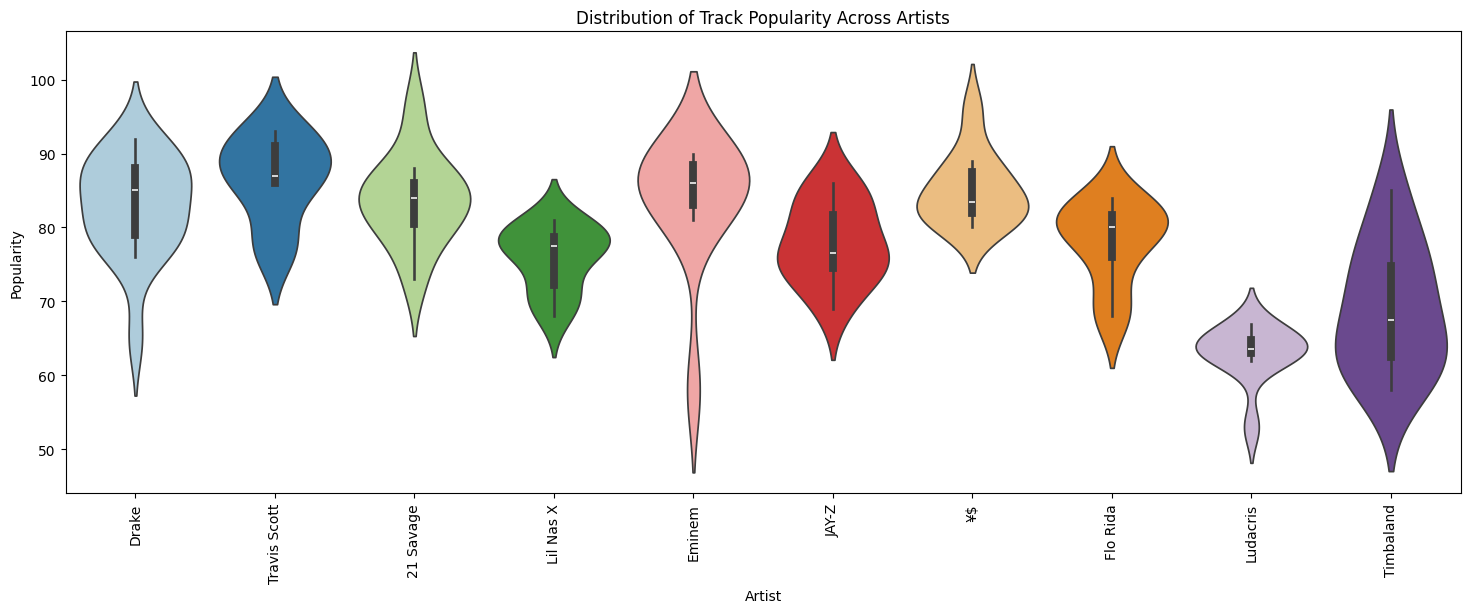

In [247]:
#Q10.  How does the distribution of track popularity vary for different artists? Visualize this using a swarm plot or a violin plot.

# Set figure size
plt.figure(figsize=(18, 6))

# Violin Plot
sns.violinplot(x='Artist', y='Popularity', data=df_top, palette='Paired')
plt.xticks(rotation=90)  # Rotate artist names for better visibility
plt.title('Distribution of Track Popularity Across Artists')
plt.show()


Drake, Travis Scott, 21 Savage, Eminem, and $s show similar patterns with high median popularity scores (around 80-85) and relatively tight distributions, indicating consistently popular tracks. Lil Nas X shows a more concentrated distribution but with slightly lower median popularity. Ludacris and Timbaland show the widest distributions and lowest median popularity scores, suggesting more variation in their track performance.